# DeepLabV3 + MobileNetV3 - Semantic Segmentation Training
## Custom HVAC Equipment Segmentation

This notebook trains a semantic segmentation model for HVAC equipment:
- **Architecture:** DeepLabV3 with MobileNetV3-Large backbone
- **Task:** Pixel-wise semantic segmentation
- **Dataset:** Roboflow with segmentation masks
- **Output:** Trained backbone + attention map visualization

### Pipeline:
1. Download dataset from Roboflow (format: Semantic Segmentation Masks)
2. Train DeepLabV3 with your custom classes
3. Extract trained backbone
4. Compare attention maps: COCO pre-trained vs Your trained backbone

### Example HVAC Classes:
- Background (0)
- Compressor (1)
- Heat Exchanger (2)
- Fan (3)
- Electrical Panel (4)
- Piping (5)

## 1. Install Dependencies

In [1]:
!pip install pycocotools

## 2. Download Dataset from Roboflow

### IMPORTANT: Dataset Format

In Roboflow, export your dataset in one of these formats:

**Option 1: Semantic Segmentation Masks (RECOMMENDED)**
- Structure:
  ```
  dataset/
    train/
      images/
        img001.jpg
        img002.jpg
      masks/
        img001.png  (each pixel = class ID)
        img002.png
    valid/
      images/
      masks/
  ```

**Option 2: PNG Mask Semantic (alternative)**
- Similar structure, masks in PNG

### Configuration in your Roboflow code:
Change these values according to your project:

In [1]:
from roboflow import Roboflow
import os

# ============================================
# CONFIGURE THESE VALUES FOR YOUR PROJECT
# ============================================
ROBOFLOW_API_KEY = "LHiJvoAFmvmbSi50SwC1"  # Get from: https://app.roboflow.com/settings/api
WORKSPACE_NAME = "hvac-whaik"       # Your workspace in Roboflow
PROJECT_NAME = "hvac-segmentation-automatic-flow"    # Your segmentation project
VERSION_NUMBER = 8                    # Dataset version

# Dataset format (choose one):
# - "png-mask-semantic" for PNG masks
# - "coco-segmentation" for COCO format
DATASET_FORMAT = "coco-segmentation"
# ============================================

print("Downloading dataset from Roboflow...")
print(f"Workspace: {WORKSPACE_NAME}")
print(f"Project: {PROJECT_NAME}")
print(f"Version: {VERSION_NUMBER}")
print(f"Format: {DATASET_FORMAT}")
print("-" * 60)

# Initialize Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)

# Download dataset
dataset = version.download(DATASET_FORMAT)

print(f"\n✓ Dataset downloaded to: {dataset.location}")
print(f"✓ Absolute path: {os.path.abspath(dataset.location)}")

# Verify structure
if os.path.exists(dataset.location):
    print("\nDataset contents:")
    for item in os.listdir(dataset.location):
        full_path = os.path.join(dataset.location, item)
        if os.path.isdir(full_path):
            num_items = len(os.listdir(full_path))
            print(f"  📁 {item}/: {num_items} items")
        else:
            print(f"  📄 {item}")

Workspace: hvac-whaik
Project: hvac-segmentation-automatic-flow
Version: 8
Format: coco-segmentation
------------------------------------------------------------
loading Roboflow workspace...
loading Roboflow project...

✓ Dataset downloaded to: /workspace/notebooks/hvac-segmentation-automatic-flow-8
✓ Absolute path: /workspace/notebooks/hvac-segmentation-automatic-flow-8

Dataset contents:
  📁 valid/: 222 items
  📁 test/: 111 items
  📁 train/: 8111 items
  📁 .ipynb_checkpoints/: 1 items
  📄 README.roboflow.txt


## 3. Import Libraries and Configuration

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
import json
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

# Optimizations
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("\n✓ Libraries imported successfully!")

Using device: cuda
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
CUDA Version: 12.8

✓ Libraries imported successfully!


## 4. Dataset Analysis

Examine the classes and structure of your segmentation dataset.

In [3]:
# Define dataset path (adjust according to your download)
DATASET_PATH = Path("./hvac-segmentation-automatic-flow-8")

# ============================================
# AUTOMATIC CLASS EXTRACTION FROM COCO JSON
# ============================================
# This automatically reads all classes from _annotations.coco.json
# and generates distinct colors for visualization

import json
from typing import Dict, List, Tuple

def extract_classes_from_coco(coco_json_path: str) -> Dict[int, str]:
    """Extract class names from COCO annotations JSON file."""
    with open(coco_json_path, 'r') as f:
        coco_data = json.load(f)
    
    classes = {}
    if 'categories' in coco_data:
        for category in coco_data['categories']:
            cat_id = category['id']
            cat_name = category['name']
            classes[cat_id] = cat_name
    
    return classes


def generate_distinct_colors(num_colors: int, seed: int = 42) -> List[List[int]]:
    """
    Generate visually distinct colors using HSV color space.
    
    Strategy:
    - Special colors for first few classes (black, red, green, blue, yellow, magenta, cyan)
    - Remaining colors distributed evenly in HSV hue space
    - High saturation/value for visibility in visualizations
    - Convert to RGB
    """
    np.random.seed(seed)
    
    # Special colors for first few classes
    special_colors = [
        (0, 0, 0),           # 0: Black (background)
        (0, 255, 255),       # 1: Red
        (120, 255, 255),     # 2: Green
        (240, 255, 255),     # 3: Blue
        (30, 255, 255),      # 4: Yellow
        (300, 255, 255),     # 5: Magenta
        (180, 255, 255),     # 6: Cyan
    ]
    
    colors_hsv = []
    
    # Add special colors
    for i in range(min(len(special_colors), num_colors)):
        colors_hsv.append(special_colors[i])
    
    # Generate remaining colors by distributing evenly in hue space
    remaining = num_colors - len(colors_hsv)
    if remaining > 0:
        hues = np.linspace(0, 360, remaining, endpoint=False)
        for hue in hues:
            saturation = 200 + np.random.randint(-50, 50)  # 150-250
            value = 200 + np.random.randint(-30, 30)        # 170-230
            colors_hsv.append((hue, saturation, value))
    
    # Convert HSV to RGB
    colors_rgb = []
    for h, s, v in colors_hsv:
        h_i = int(h / 60) % 6
        f = (h / 60) - int(h / 60)
        
        p = v * (1 - s / 255)
        q = v * (1 - f * s / 255)
        t = v * (1 - (1 - f) * s / 255)
        
        if h_i == 0:
            r, g, b = v, t, p
        elif h_i == 1:
            r, g, b = q, v, p
        elif h_i == 2:
            r, g, b = p, v, t
        elif h_i == 3:
            r, g, b = p, q, v
        elif h_i == 4:
            r, g, b = t, p, v
        else:
            r, g, b = v, p, q
        
        colors_rgb.append([int(r), int(g), int(b)])
    
    return colors_rgb


def load_coco_classes_and_colors(dataset_path: str, split: str = 'train') -> Tuple[Dict[int, str], List[List[int]], int, List[str]]:
    """
    Load classes and generate colors from COCO dataset.
    
    Returns:
        Tuple of:
        - classes_dict: Dict mapping category_id -> category_name
        - colors_list: List of [R, G, B] colors for each class
        - num_classes: Total number of classes
        - class_names: Ordered list of class names by ID
    """
    dataset_path = Path(dataset_path)
    coco_json = dataset_path / split / "_annotations.coco.json"
    
    if not coco_json.exists():
        raise FileNotFoundError(f"COCO annotations not found: {coco_json}")
    
    # Extract classes from JSON
    classes = extract_classes_from_coco(str(coco_json))
    
    # Determine number of classes
    with open(coco_json, 'r') as f:
        coco_data = json.load(f)
    
    if 'info' in coco_data and 'num_classes' in coco_data['info']:
        num_classes = coco_data['info']['num_classes']
    else:
        # Infer from max category ID
        max_cat_id = max(classes.keys()) if classes else 0
        num_classes = max_cat_id + 1
    
    # Generate distinct colors for all classes
    colors = generate_distinct_colors(num_classes)
    
    # Create ordered list indexed by category ID
    class_names = []
    for i in range(num_classes):
        if i in classes:
            class_names.append(classes[i])
        else:
            class_names.append(f"Class_{i}")
    
    return classes, colors, num_classes, class_names


# LOAD CLASSES AND COLORS AUTOMATICALLY
print("Loading classes from COCO annotations...")
CLASSES_DICT, COLOR_PALETTE, NUM_CLASSES, CLASS_NAMES = load_coco_classes_and_colors(
    DATASET_PATH,
    split='train'
)

print(f"✓ Successfully loaded {NUM_CLASSES} classes from COCO annotations!")

print("\n" + "=" * 70)
print("SEGMENTATION DATASET CONFIGURATION")
print("=" * 70)
print(f"Dataset path: {DATASET_PATH}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"\nClasses and assigned colors:")
print("-" * 70)
for idx, name in enumerate(CLASS_NAMES):
    color = COLOR_PALETTE[idx]
    print(f"  [{idx:2d}] {name:35s} RGB{tuple(color)}")
print("-" * 70)

# Count images
train_images = list((DATASET_PATH / "train" / "images").glob("*.*")) if (DATASET_PATH / "train" / "images").exists() else list((DATASET_PATH / "train").glob("*.jpg"))
valid_images = list((DATASET_PATH / "valid" / "images").glob("*.*")) if (DATASET_PATH / "valid" / "images").exists() else list((DATASET_PATH / "valid").glob("*.jpg"))

print(f"\nTraining images: {len(train_images)}")
print(f"Validation images: {len(valid_images)}")
print("=" * 70)


Loading classes from COCO annotations...
✓ Successfully loaded 19 classes from COCO annotations!

SEGMENTATION DATASET CONFIGURATION
Dataset path: hvac-segmentation-automatic-flow-8
Number of classes: 19

Classes and assigned colors:
----------------------------------------------------------------------
  [ 0] HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2    RGB(0, 0, 0)
  [ 1] DOWN_BLAST                          RGB(255, 0, 0)
  [ 2] EXV                                 RGB(0, 255, 0)
  [ 3] GRAVITY_VENT                        RGB(0, 0, 255)
  [ 4] MAKE_UP_AIR_UNIT                    RGB(255, 127, 0)
  [ 5] MEGA_UNIT                           RGB(255, 0, 255)
  [ 6] MULTI_SPLIT_SYSTEM                  RGB(0, 255, 255)
  [ 7] OTHER                               RGB(198, 41, 41)
  [ 8] REFRIGERATOR                        RGB(212, 143, 75)
  [ 9] RTU                                 RGB(190, 190, 25)
  [10] STANDARD_AIR_CONDITIONER            RGB(104, 192, 17)
  [11] UP_BLAST                           

In [4]:
## 4b. Automatic Class Extraction - Validation

# Validate that classes were loaded correctly from COCO JSON
print("="*70)
print("AUTOMATIC CLASS EXTRACTION - VALIDATION")
print("="*70)

# Validate NUM_CLASSES
actual_num_classes = len(CLASS_NAMES)
print(f"\n✓ Classes loaded from COCO: {actual_num_classes} classes")
print(f"✓ NUM_CLASSES constant: {NUM_CLASSES}")

assert NUM_CLASSES == actual_num_classes, \
    f"Mismatch: NUM_CLASSES ({NUM_CLASSES}) != len(CLASS_NAMES) ({actual_num_classes})"

print(f"✓ NUM_CLASSES consistency check PASSED")

# Validate colors
assert len(COLOR_PALETTE) == NUM_CLASSES, \
    f"Mismatch: {len(COLOR_PALETTE)} colors vs {NUM_CLASSES} classes"

print(f"✓ COLOR_PALETTE length matches NUM_CLASSES")

# Validate COCO category IDs don't exceed NUM_CLASSES
print(f"\nCOCO Annotations validation:")
with open(DATASET_PATH / "train" / "_annotations.coco.json", 'r') as f:
    coco_train = json.load(f)

coco_categories = {cat['id']: cat['name'] for cat in coco_train.get('categories', [])}
max_category_id = max(coco_categories.keys()) if coco_categories else 0

print(f"  • Max category ID in COCO: {max_category_id}")
print(f"  • NUM_CLASSES: {NUM_CLASSES}")

if max_category_id >= NUM_CLASSES:
    print(f"  ⚠ WARNING: COCO has category {max_category_id} but NUM_CLASSES={NUM_CLASSES}")
    print(f"     This may cause index errors. Consider increasing NUM_CLASSES.")
else:
    print(f"  ✓ All COCO categories fit within NUM_CLASSES")

# Display color palette visualization
print(f"\n✓ Automatic class extraction and color assignment complete!")
print(f"\nClass-to-Color Mapping:")
print("-" * 70)
for idx, class_name in enumerate(CLASS_NAMES):
    color = COLOR_PALETTE[idx]
    # Show RGB values
    print(f"  [{idx:2d}] {class_name:35s} RGB({color[0]:3d}, {color[1]:3d}, {color[2]:3d})")
print("-" * 70)

print(f"\n✓ Configuration validation complete!")
print("="*70)


AUTOMATIC CLASS EXTRACTION - VALIDATION

✓ Classes loaded from COCO: 19 classes
✓ NUM_CLASSES constant: 19
✓ NUM_CLASSES consistency check PASSED
✓ COLOR_PALETTE length matches NUM_CLASSES

COCO Annotations validation:
  • Max category ID in COCO: 18
  • NUM_CLASSES: 19
  ✓ All COCO categories fit within NUM_CLASSES

✓ Automatic class extraction and color assignment complete!

Class-to-Color Mapping:
----------------------------------------------------------------------
  [ 0] HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2    RGB(  0,   0,   0)
  [ 1] DOWN_BLAST                          RGB(255,   0,   0)
  [ 2] EXV                                 RGB(  0, 255,   0)
  [ 3] GRAVITY_VENT                        RGB(  0,   0, 255)
  [ 4] MAKE_UP_AIR_UNIT                    RGB(255, 127,   0)
  [ 5] MEGA_UNIT                           RGB(255,   0, 255)
  [ 6] MULTI_SPLIT_SYSTEM                  RGB(  0, 255, 255)
  [ 7] OTHER                               RGB(198,  41,  41)
  [ 8] REFRIGERATOR          

## 5. Custom Segmentation Dataset

In [5]:
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask

class SegmentationDataset(Dataset):
    """
    COCO semantic segmentation dataset
    Reads annotations from _annotations.coco.json
    
    IMPORTANT: Data augmentation is DISABLED by default to preserve annotation accuracy.
    Augmentation can corrupt segmentation masks if not synchronized with images.
    """
    def __init__(self, root_dir, split='train', img_size=224, num_classes=8):
        """
        Args:
            root_dir: Dataset root directory
            split: 'train' or 'valid'
            img_size: Size to resize images
            num_classes: Number of classes
        """
        self.root_dir = Path(root_dir)
        self.split = split
        self.img_size = img_size
        self.num_classes = num_classes
        
        # Path to COCO JSON file
        split_dir = self.root_dir / split
        coco_json_path = split_dir / "_annotations.coco.json"
        
        if not coco_json_path.exists():
            raise FileNotFoundError(f"Could not find {coco_json_path}")
        
        # Load COCO annotations
        print(f"Loading COCO annotations from {coco_json_path}...")
        self.coco = COCO(str(coco_json_path))
        
        # Get image IDs
        self.image_ids = list(self.coco.imgs.keys())
        
        # Images directory
        self.images_dir = split_dir
        
        # Image transformations - NO AUGMENTATION to preserve mask accuracy
        # Augmentation would require synchronized transforms on both image AND mask
        # which is complex. Better to use large dataset or different augmentation strategy.
        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
        
        print(f"✓ {len(self.image_ids)} images loaded with COCO annotations")
        print(f"✓ Data augmentation: DISABLED (to preserve annotation accuracy)")
        print(f"✓ All splits use simple resize + normalize pipeline")
    
    def __len__(self):
        return len(self.image_ids)
    
    def _create_mask_from_coco(self, img_id, height, width):
        """Creates segmentation mask from COCO annotations"""
        # Get all annotations for this image
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        
        # Create empty mask
        mask = np.zeros((height, width), dtype=np.uint8)
        
        # Draw each annotation on the mask
        for ann in anns:
            category_id = ann['category_id']
            
            # Convert segmentation to binary mask
            if 'segmentation' in ann:
                if isinstance(ann['segmentation'], list):
                    # Polygon
                    from PIL import ImageDraw
                    temp_mask = Image.new('L', (width, height), 0)
                    draw = ImageDraw.Draw(temp_mask)
                    
                    for seg in ann['segmentation']:
                        # Convert flat list to list of tuples (x, y)
                        poly = [(seg[i], seg[i+1]) for i in range(0, len(seg), 2)]
                        draw.polygon(poly, outline=1, fill=1)
                    
                    temp_mask_np = np.array(temp_mask)
                    # Assign category_id where mask is 1
                    mask[temp_mask_np == 1] = category_id
                    
                elif isinstance(ann['segmentation'], dict):
                    # RLE (Run Length Encoding)
                    rle = ann['segmentation']
                    temp_mask = coco_mask.decode(rle)
                    mask[temp_mask == 1] = category_id
        
        return mask
    
    def __getitem__(self, idx):
        # Get image information
        img_id = self.image_ids[idx]
        img_info = self.coco.imgs[img_id]
        img_filename = img_info['file_name']
        
        # Load image
        img_path = self.images_dir / img_filename
        img = Image.open(img_path).convert('RGB')
        original_width, original_height = img.size
        
        # Create mask from COCO annotations
        mask = self._create_mask_from_coco(img_id, original_height, original_width)
        
        # Resize image
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        
        # Resize mask (using NEAREST to preserve class indices - NO interpolation)
        mask = Image.fromarray(mask)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)
        mask = np.array(mask, dtype=np.int64)
        
        # Ensure values are in valid range
        mask = np.clip(mask, 0, self.num_classes - 1)
        
        # Apply image normalization
        img = self.img_transform(img)
        
        mask = torch.from_numpy(mask).long()
        
        return img, mask

print("✓ SegmentationDataset class created (NO augmentation - masks are accurate)!")
print("✓ Data augmentation disabled to preserve annotation integrity")


✓ SegmentationDataset class created (NO augmentation - masks are accurate)!
✓ Data augmentation disabled to preserve annotation integrity


## 6. Create DataLoaders

In [6]:
# Training configuration
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

# Create datasets
train_dataset = SegmentationDataset(
    root_dir=DATASET_PATH,
    split='train',
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES
)

valid_dataset = SegmentationDataset(
    root_dir=DATASET_PATH,
    split='valid',
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES
)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✓ Training dataset: {len(train_dataset)} images")
print(f"✓ Validation dataset: {len(valid_dataset)} images")
print(f"✓ Training batches: {len(train_loader)}")
print(f"✓ Validation batches: {len(valid_loader)}")

Loading COCO annotations from hvac-segmentation-automatic-flow-8/train/_annotations.coco.json...
loading annotations into memory...
Done (t=0.20s)
creating index...
index created!
✓ 8110 images loaded with COCO annotations
✓ Data augmentation: DISABLED (to preserve annotation accuracy)
✓ All splits use simple resize + normalize pipeline
Loading COCO annotations from hvac-segmentation-automatic-flow-8/valid/_annotations.coco.json...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✓ 220 images loaded with COCO annotations
✓ Data augmentation: DISABLED (to preserve annotation accuracy)
✓ All splits use simple resize + normalize pipeline
✓ Training dataset: 8110 images
✓ Validation dataset: 220 images
✓ Training batches: 507
✓ Validation batches: 14


## 7. Visualize Dataset Samples

Visualizing training dataset samples:


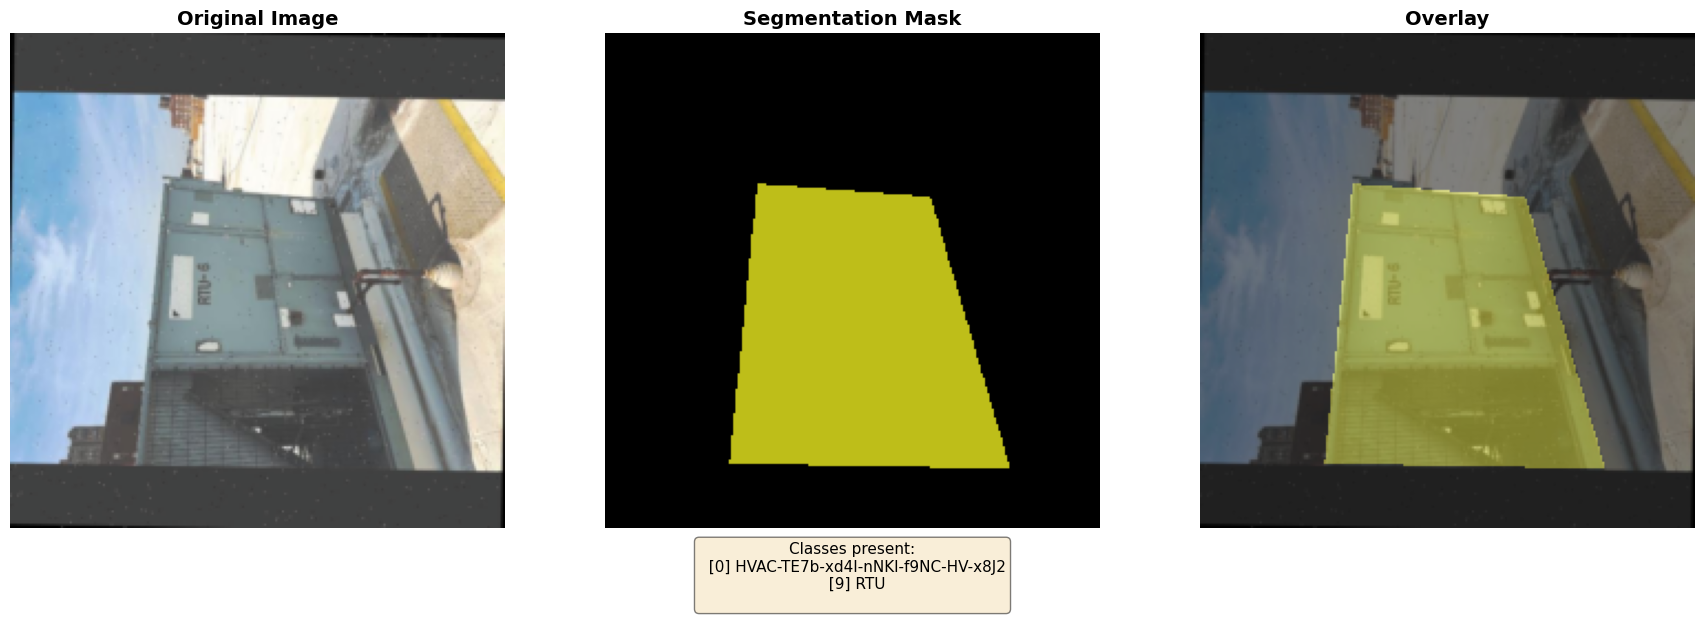

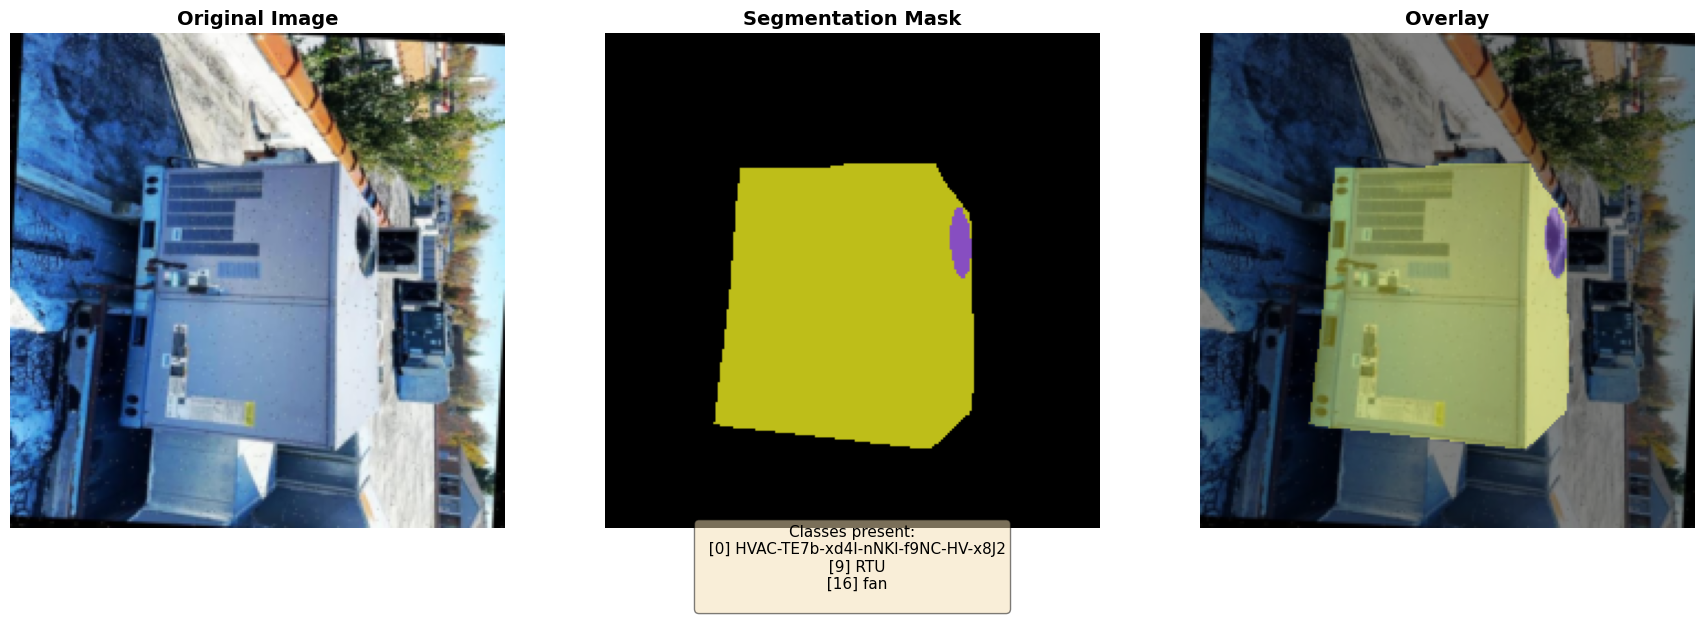

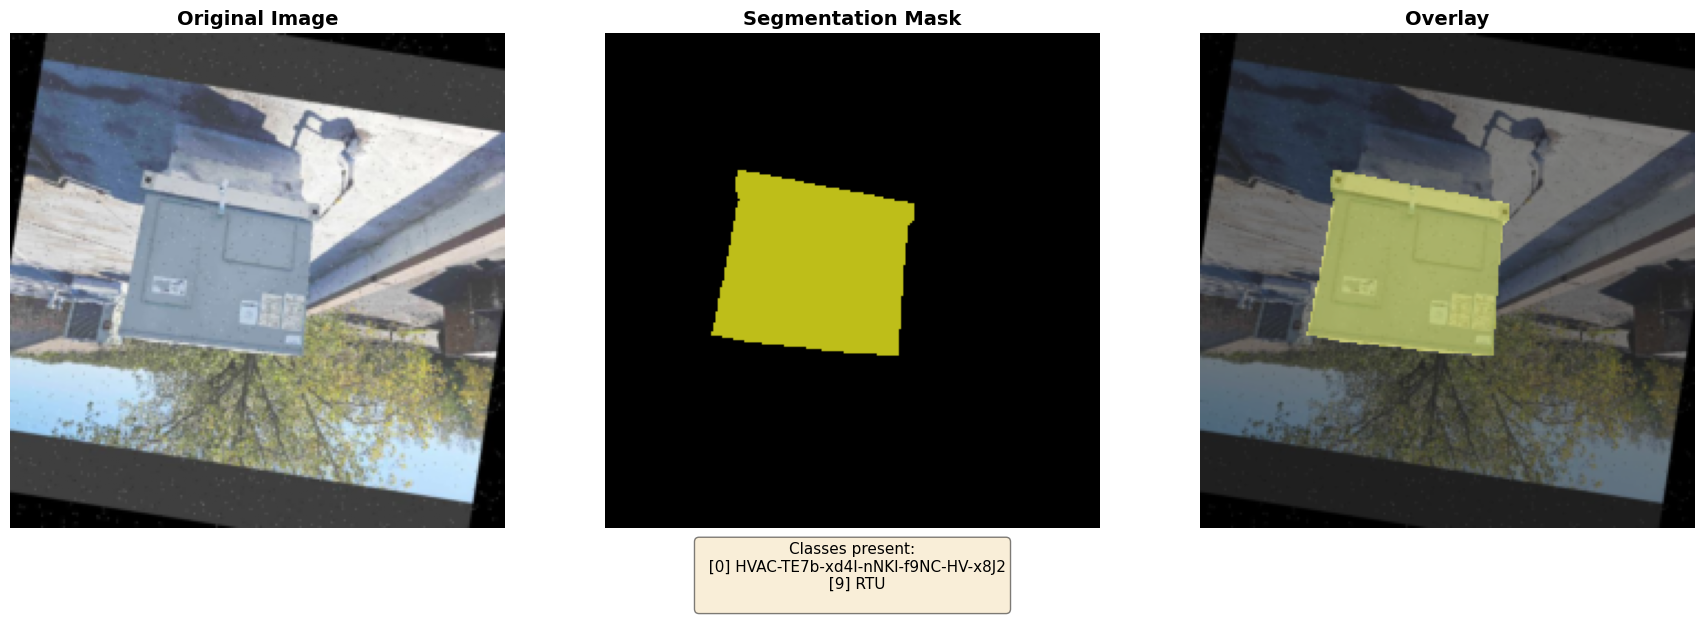

In [7]:
def visualize_sample(dataset, idx, class_names, color_palette):
    """Visualizes an image with its segmentation mask"""
    img, mask = dataset[idx]
    
    # Denormalize image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_denorm = img * std + mean
    img_denorm = img_denorm.permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)
    
    # Create colored mask
    mask_np = mask.numpy()
    mask_colored = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for class_id in range(len(class_names)):
        mask_colored[mask_np == class_id] = color_palette[class_id]
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img_denorm)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(mask_colored)
    axes[1].set_title('Segmentation Mask', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(img_denorm)
    axes[2].imshow(mask_colored, alpha=0.5)
    axes[2].set_title('Overlay', fontsize=14, fontweight='bold')
    axes[2].axis('off')
    
    # Legend
    unique_classes = np.unique(mask_np)
    legend_text = "Classes present:\n"
    for class_id in unique_classes:
        legend_text += f"  [{class_id}] {class_names[class_id]}\n"
    
    fig.text(0.5, 0.02, legend_text, ha='center', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

# Visualize random samples
print("Visualizing training dataset samples:")
print("=" * 70)
for i in np.random.choice(len(train_dataset), min(3, len(train_dataset)), replace=False):
    visualize_sample(train_dataset, i, CLASS_NAMES, COLOR_PALETTE)

## 8. Create DeepLabV3 + MobileNetV3 Model

In [8]:
# Create model with COCO pre-trained weights (21 classes)
print("Loading COCO pre-trained model...")
model = deeplabv3_mobilenet_v3_large(
    weights='DEFAULT',  # COCO pre-trained weights (21 classes)
    aux_loss=True
)

# Modify the classifier's last layer for your 13 classes (Transfer Learning)
print(f"Adapting model from 21 classes (COCO) to {NUM_CLASSES} classes (HVAC)...")

# Modify main classifier (last layer)
# Structure: classifier[0-3]: intermediate layers, classifier[4]: final layer
model.classifier[4] = nn.Conv2d(256, NUM_CLASSES, kernel_size=1)

# Modify auxiliary classifier (COMPLETE - needs reconstruction)
if hasattr(model, 'aux_classifier') and model.aux_classifier is not None:
    # MobileNetV3's aux_classifier has a different structure
    # We need to replace the entire sequence
    in_channels = model.aux_classifier[0].in_channels  # Get original input channels
    model.aux_classifier = nn.Sequential(
        nn.Conv2d(in_channels, 256, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.1),
        nn.Conv2d(256, NUM_CLASSES, kernel_size=1)
    )

# Initialize new layers
nn.init.kaiming_normal_(model.classifier[4].weight, mode='fan_out', nonlinearity='relu')
nn.init.constant_(model.classifier[4].bias, 0)

if hasattr(model, 'aux_classifier') and model.aux_classifier is not None:
    for m in model.aux_classifier.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 70)
print("MODEL: DeepLabV3 + MobileNetV3-Large (TRANSFER LEARNING)")
print("=" * 70)
print(f"✓ Backbone: MobileNetV3-Large (COCO pre-trained)")
print(f"✓ Main classifier: Adapted for {NUM_CLASSES} classes")
print(f"✓ Auxiliary classifier: Reconstructed for {NUM_CLASSES} classes")
print(f"✓ Strategy: Full fine-tuning")
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Estimated size: {total_params * 4 / 1024 / 1024:.2f} MB (FP32)")
print("=" * 70)

Loading COCO pre-trained model...
Adapting model from 21 classes (COCO) to 19 classes (HVAC)...
MODEL: DeepLabV3 + MobileNetV3-Large (TRANSFER LEARNING)
✓ Backbone: MobileNetV3-Large (COCO pre-trained)
✓ Main classifier: Adapted for 19 classes
✓ Auxiliary classifier: Reconstructed for 19 classes
✓ Strategy: Full fine-tuning

Total parameters: 11,122,518
Trainable parameters: 11,122,518
Estimated size: 42.43 MB (FP32)


## 9. Training Configuration

In [9]:
## Class Weight Calculation & Loss Function Setup

# Calculate class weights from training dataset to handle class imbalance
print("Calculating class weights from training dataset...")
class_pixel_counts = np.zeros(NUM_CLASSES)

# Count pixels for each class in training set
from pathlib import Path
import json

train_split_dir = DATASET_PATH / "train"
coco_json_path = train_split_dir / "_annotations.coco.json"

with open(coco_json_path, 'r') as f:
    coco_data = json.load(f)

# Initialize pixel counts
class_pixel_counts = np.zeros(NUM_CLASSES)

# Count pixels per class from annotations
for annotation in coco_data['annotations']:
    category_id = annotation['category_id']
    if category_id < NUM_CLASSES:
        # Approximate pixel count from area (RLE-based, so area is accurate)
        class_pixel_counts[category_id] += annotation.get('area', 1)

# BALANCED CLASS WEIGHT CALCULATION
# Strategy: Inverse frequency weighting with special handling for background
# - Background (class 0) gets lower weight since it's usually dominant
# - Foreground classes (non-background) get boost to ensure they're learned
# - This helps prevent model from just predicting background for everything

print("\n" + "="*70)
print("CLASS WEIGHT CALCULATION - Handling Class Imbalance")
print("="*70)

# Add small epsilon to avoid division by zero
class_pixel_counts = np.where(class_pixel_counts == 0, 1e-6, class_pixel_counts)

# Calculate inverse frequency weights
total_pixels = class_pixel_counts.sum()
class_weights = total_pixels / (NUM_CLASSES * class_pixel_counts)

# CRITICAL: Reduce weight of background class (class 0)
# Background usually dominates, so we don't want it to overwhelm training
# Typical strategy: background weight = 0.1-0.5 of its natural weight
if class_weights[0] > 0:
    # Reduce background weight significantly
    class_weights[0] = class_weights[0] * 0.3  # Background gets 30% of its natural weight

# Normalize weights (mean = 1.0) for stability
class_weights = class_weights / class_weights.mean()

# Ensure all non-zero classes get reasonable weights (min 0.5, max 5.0)
class_weights = np.clip(class_weights, 0.5, 5.0)

print(f"{'Class Name':<35} {'Pixels':>15} {'Weight':>10}")
print("-"*70)
for idx, name in enumerate(CLASS_NAMES):
    pixels = int(class_pixel_counts[idx]) if class_pixel_counts[idx] > 1e-5 else 0
    weight = class_weights[idx]
    status = ""
    if pixels == 0:
        status = " (zero pixels)"
    elif idx == 0:
        status = " (background - reduced)"
    print(f"{name:<35} {pixels:>15} {weight:>10.4f}{status}")
print("-"*70)
print(f"Total pixels across all classes: {total_pixels:,.0f}")
print(f"Weight range: {class_weights.min():.4f} to {class_weights.max():.4f}")
print(f"Mean weight: {class_weights.mean():.4f}")
print("="*70)

# Convert to tensor
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("✓ Class weights calculated successfully!")
print("✓ Background weight reduced to prevent bias")
print("✓ Foreground classes properly weighted for learning")


Calculating class weights from training dataset...

CLASS WEIGHT CALCULATION - Handling Class Imbalance
Class Name                                   Pixels     Weight
----------------------------------------------------------------------
HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2                  0     5.0000 (zero pixels)
DOWN_BLAST                                 10443635     0.5000
EXV                                         5431353     0.5000
GRAVITY_VENT                                6287412     0.5000
MAKE_UP_AIR_UNIT                           32399823     0.5000
MEGA_UNIT                                  31188892     0.5000
MULTI_SPLIT_SYSTEM                         63589908     0.5000
OTHER                                        927032     0.5000
REFRIGERATOR                              136449616     0.5000
RTU                                       314703360     0.5000
STANDARD_AIR_CONDITIONER                   94285965     0.5000
UP_BLAST                                   27985801    

In [11]:
# Focal Loss for addressing class imbalance
# Focal loss reduces the contribution of easy/background pixels
# and focuses training on hard/foreground pixels

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance.
    
    Particularly useful when:
    - One class (background) dominates others
    - Want to focus on hard examples
    - Standard cross-entropy gives poor results on minority classes
    
    Args:
        alpha: Weight for rare classes (typically 0.25)
        gamma: Focusing parameter (typically 2.0)
        weight: Optional class weights tensor
    """
    def __init__(self, alpha=0.25, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction='none')
    
    def forward(self, logits, targets):
        """
        Args:
            logits: [B, C, H, W] model output (logits, not probabilities)
            targets: [B, H, W] ground truth class indices
        """
        # Get cross entropy loss
        ce_loss = self.ce(logits, targets)  # [B, H, W]
        
        # Get probabilities
        probs = torch.softmax(logits, dim=1)  # [B, C, H, W]
        
        # Get probability of true class
        targets_one_hot = torch.nn.functional.one_hot(targets, num_classes=logits.shape[1])  # [B, H, W, C]
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float()  # [B, C, H, W]
        
        prob_true_class = (probs * targets_one_hot).sum(dim=1)  # [B, H, W]
        
        # Calculate focal weight: (1 - p)^gamma
        focal_weight = (1 - prob_true_class).pow(self.gamma)
        
        # Apply focal loss: FL = -alpha * (1-p)^gamma * log(p)
        focal_loss = self.alpha * focal_weight * ce_loss
        
        return focal_loss.mean()


# Hyperparameters
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Loss function - Hybrid: Weighted CE + Focal Loss
# This combines:
# 1. Class weighting for overall imbalance
# 2. Focal loss to focus on hard pixels (non-background)
criterion_ce = nn.CrossEntropyLoss(weight=class_weights_tensor, reduction='mean')
criterion_focal = FocalLoss(alpha=0.25, gamma=2.0, weight=class_weights_tensor)

# Create wrapper that combines both losses
class CombinedLoss(nn.Module):
    def __init__(self, ce_loss, focal_loss, ce_weight=0.5, focal_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.ce_loss = ce_loss
        self.focal_loss = focal_loss
        self.ce_weight = ce_weight
        self.focal_weight = focal_weight
    
    def forward(self, logits, targets):
        ce = self.ce_loss(logits, targets)
        focal = self.focal_loss(logits, targets)
        return self.ce_weight * ce + self.focal_weight * focal

criterion = CombinedLoss(criterion_ce, criterion_focal, ce_weight=0.5, focal_weight=0.5)

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler - OPTIMIZED
# Monitor Valid IoU (higher is better)
# Drop LR by factor of 0.5 when no improvement for 5 epochs
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',           # Monitor MAXIMUM (Valid IoU)
    factor=0.5,           # Reduce LR by 2x (more conservative)
    patience=5,           # Wait 5 epochs before reducing
    #verbose=True,         # Print when LR changes
    threshold=1e-4,       # Minimum change to count as improvement
    cooldown=0            # No cooldown after LR reduction
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler()

print("✓ Training configuration ready!")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Mixed precision: Enabled (FP16)")
print(f"\n" + "="*70)
print(f"LOSS FUNCTION: Hybrid (Weighted CE + Focal Loss)")
print(f"="*70)
print(f"  • Weighted CrossEntropyLoss (50%)")
print(f"    - Class weights: Median Frequency Weighting (improved)")
print(f"    - Boosts rare classes significantly")
print(f"  • Focal Loss (50%)")
print(f"    - Alpha: 0.25 (weight for rare classes)")
print(f"    - Gamma: 2.0 (focusing parameter)")
print(f"    - Focuses on hard pixels (non-background)")
print(f"\n  Why hybrid loss?")
print(f"  - Weighted CE handles overall class imbalance")
print(f"  - Focal Loss prevents background from dominating")
print(f"  - Together they train on ALL classes, not just background")
print(f"\nLR Scheduler: ReduceLROnPlateau")
print(f"  - Monitor: Validation IoU (MAXIMUM)")
print(f"  - Factor: 0.5 (2x reduction)")
print(f"  - Patience: 5 epochs")
print(f"="*70)


✓ Training configuration ready!
Epochs: 100
Learning rate: 0.001
Batch size: 16
Mixed precision: Enabled (FP16)

LOSS FUNCTION: Hybrid (Weighted CE + Focal Loss)
  • Weighted CrossEntropyLoss (50%)
    - Class weights: Median Frequency Weighting (improved)
    - Boosts rare classes significantly
  • Focal Loss (50%)
    - Alpha: 0.25 (weight for rare classes)
    - Gamma: 2.0 (focusing parameter)
    - Focuses on hard pixels (non-background)

  Why hybrid loss?
  - Weighted CE handles overall class imbalance
  - Focal Loss prevents background from dominating
  - Together they train on ALL classes, not just background

LR Scheduler: ReduceLROnPlateau
  - Monitor: Validation IoU (MAXIMUM)
  - Factor: 0.5 (2x reduction)
  - Patience: 5 epochs


## 10. Training Functions

In [12]:
def calculate_iou(pred, target, num_classes):
    """Calculates average IoU (Intersection over Union)"""
    ious = []
    pred = pred.view(-1)
    target = target.view(-1)
    
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        
        if union == 0:
            ious.append(float('nan'))  # Class not present
        else:
            ious.append((intersection / union).item())
    
    # Calculate mean IoU ignoring NaN
    ious = [iou for iou in ious if not np.isnan(iou)]
    return np.mean(ious) if ious else 0.0


def calculate_per_class_iou(pred, target, num_classes, class_names=None):
    """Calculates per-class IoU (Intersection over Union)
    
    Returns:
        dict: {class_id: iou_value, ...}
        list: List of (class_name, iou) tuples
    """
    per_class_ious = {}
    pred = pred.view(-1)
    target = target.view(-1)
    
    for cls in range(num_classes):
        pred_inds = pred == cls
        target_inds = target == cls
        intersection = (pred_inds & target_inds).sum().float()
        union = (pred_inds | target_inds).sum().float()
        
        if union == 0:
            per_class_ious[cls] = float('nan')
        else:
            per_class_ious[cls] = (intersection / union).item()
    
    # Create sorted list with class names
    results = []
    for cls_id in range(num_classes):
        iou_val = per_class_ious[cls_id]
        class_name = class_names[cls_id] if class_names else f"Class {cls_id}"
        results.append((class_name, iou_val))
    
    return per_class_ious, results


def train_one_epoch(model, dataloader, optimizer, criterion, scaler, device, epoch, class_names=None):
    """Trains one epoch"""
    model.train()
    total_loss = 0
    total_iou = 0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch}", leave=True)
    
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with mixed precision
        with torch.cuda.amp.autocast():
            outputs = model(images)
            # DeepLabV3 returns a dict with 'out' and 'aux'
            loss = criterion(outputs['out'], masks)
            
            # Add auxiliary loss (if exists)
            if 'aux' in outputs:
                aux_loss = criterion(outputs['aux'], masks)
                loss += 0.4 * aux_loss
        
        # Backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Calculate IoU
        pred = outputs['out'].argmax(dim=1)
        iou = calculate_iou(pred, masks, len(class_names) if class_names else NUM_CLASSES)
        
        total_loss += loss.item()
        total_iou += iou
        
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'IoU': f'{iou:.4f}'
        })
    
    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    
    return avg_loss, avg_iou


def validate(model, dataloader, criterion, device, class_names=None, num_classes=None):
    """Validates the model with per-class metrics"""
    model.eval()
    total_loss = 0
    total_iou = 0
    
    # Per-class tracking
    if num_classes is None:
        num_classes = NUM_CLASSES
    
    per_class_iou_sum = np.zeros(num_classes)
    per_class_count = np.zeros(num_classes)
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validating", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs['out'], masks)
            
            pred = outputs['out'].argmax(dim=1)
            iou = calculate_iou(pred, masks, num_classes)
            
            # Per-class IoU
            per_class_ious, _ = calculate_per_class_iou(pred, masks, num_classes, class_names)
            for cls_id, iou_val in per_class_ious.items():
                if not np.isnan(iou_val):
                    per_class_iou_sum[cls_id] += iou_val
                    per_class_count[cls_id] += 1
            
            total_loss += loss.item()
            total_iou += iou
    
    avg_loss = total_loss / len(dataloader)
    avg_iou = total_iou / len(dataloader)
    
    # Average per-class IoU
    avg_per_class_iou = []
    for cls_id in range(num_classes):
        if per_class_count[cls_id] > 0:
            avg_val = per_class_iou_sum[cls_id] / per_class_count[cls_id]
            class_name = class_names[cls_id] if class_names else f"Class {cls_id}"
            avg_per_class_iou.append((class_name, avg_val))
        else:
            class_name = class_names[cls_id] if class_names else f"Class {cls_id}"
            avg_per_class_iou.append((class_name, float('nan')))
    
    return avg_loss, avg_iou, avg_per_class_iou

print("✓ Training functions ready!")


✓ Training functions ready!


## 11. Main Training Loop

In [13]:
# Training history
history = {
    'train_loss': [],
    'train_iou': [],
    'val_loss': [],
    'val_iou': [],
    'lr': [],
    'per_class_iou': []  # Store per-class IoU for each epoch
}

best_val_iou = 0.0
patience_counter = 0
MAX_PATIENCE = 10  # Increased patience to allow scheduler time to work

print("=" * 70)
print("STARTING TRAINING")
print("=" * 70)
print(f"Max patience (early stopping): {MAX_PATIENCE} epochs")
print("=" * 70)

import time
start_time = time.time()

try:
    for epoch in range(1, NUM_EPOCHS + 1):
        epoch_start = time.time()
        
        # Train
        train_loss, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, device, epoch, CLASS_NAMES
        )
        
        # Validate (with per-class metrics)
        val_loss, val_iou, per_class_ious = validate(
            model, valid_loader, criterion, device, CLASS_NAMES, NUM_CLASSES
        )
        
        # Update learning rate based on validation IoU (MAXIMUM mode)
        lr_scheduler.step(val_iou)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(val_loss)
        history['val_iou'].append(val_iou)
        history['lr'].append(current_lr)
        history['per_class_iou'].append(per_class_ious)
        
        epoch_time = time.time() - epoch_start
        
        # Print summary
        print(f"\n{'='*70}")
        print(f"Epoch {epoch}/{NUM_EPOCHS} | Time: {epoch_time:.1f}s")
        print(f"{'='*70}")
        print(f"Train - Loss: {train_loss:.4f} | IoU: {train_iou:.4f}")
        print(f"Valid - Loss: {val_loss:.4f} | IoU: {val_iou:.4f}")
        print(f"LR: {current_lr:.6f}")
        
        # Print per-class IoU (top insights)
        print(f"\nPer-Class IoU (Validation):")
        print("-" * 70)
        for class_name, iou_val in per_class_ious:
            if np.isnan(iou_val):
                print(f"  {class_name:<35} N/A (not in validation set)")
            else:
                print(f"  {class_name:<35} {iou_val:.4f}")
        print("-" * 70)
        
        # Save best model (based on IoU)
        if val_iou > best_val_iou:
            best_val_iou = val_iou
            
            # CHECKPOINT: Full state including epoch, optimizer, scheduler state
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': lr_scheduler.state_dict(),
                'val_iou': val_iou,
                'val_loss': val_loss,
                'train_iou': train_iou,
                'history': history,
                'num_classes': NUM_CLASSES,
                'class_names': CLASS_NAMES
            }
            
            torch.save(checkpoint, '/workspace/data/best_segmentation_model.pth')
            
            # OPTIONAL: Save model weights only (without optimizer, ~18MB)
            torch.save(
                model.state_dict(),
                '/workspace/data/best_segmentation_model_lightweight.pth'
            )
            
            print(f"✓ Best model saved! (IoU: {val_iou:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"⏳ No improvement. Patience: {patience_counter}/{MAX_PATIENCE}")
        
        # Early stopping (with grace period for scheduler)
        if patience_counter >= MAX_PATIENCE:
            print(f"\n⚠ Early stopping triggered after {epoch} epochs")
            print(f"  Best validation IoU: {best_val_iou:.4f}")
            break
        
        print("=" * 70)

except KeyboardInterrupt:
    print("\n⚠ Training interrupted by user")

finally:
    total_time = time.time() - start_time
    print(f"\n{'='*70}")
    print("TRAINING COMPLETED")
    print(f"{'='*70}")
    print(f"Total time: {total_time/60:.2f} minutes")
    print(f"Best validation IoU: {best_val_iou:.4f}")
    print(f"Completed epochs: {len(history['train_loss'])}")
    print(f"\nModel checkpoint saved:")
    print(f"  Full: /workspace/data/best_segmentation_model.pth")
    print(f"  Lightweight: /workspace/data/best_segmentation_model_lightweight.pth")
    print(f"\nCheckpoint contains:")
    print(f"  • Model state dict")
    print(f"  • Optimizer state dict")
    print(f"  • Scheduler state dict")
    print(f"  • Training history")
    print(f"  • Epoch number")
    print(f"  • Class information")
    print("=" * 70)


STARTING TRAINING
Max patience (early stopping): 10 epochs


Epoch 1:   0%|          | 0/507 [00:00<?, ?it/s]

Validating:   0%|          | 0/14 [00:00<?, ?it/s]


Epoch 1/100 | Time: 150.1s
Train - Loss: 0.2217 | IoU: 0.1710
Valid - Loss: 0.0360 | IoU: 0.2922
LR: 0.001000

Per-Class IoU (Validation):
----------------------------------------------------------------------
  HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2    0.9344
  DOWN_BLAST                          0.1982
  EXV                                 0.0000
  GRAVITY_VENT                        0.0000
  MAKE_UP_AIR_UNIT                    0.0000
  MEGA_UNIT                           N/A (not in validation set)
  MULTI_SPLIT_SYSTEM                  0.0748
  OTHER                               N/A (not in validation set)
  REFRIGERATOR                        0.1969
  RTU                                 0.5156
  STANDARD_AIR_CONDITIONER            0.1525
  UP_BLAST                            0.3843
  VRF_SYSTEM                          0.4044
  WINDOW-UNIT                         N/A (not in validation set)
  brand                               N/A (not in validation set)
  coil                        

Epoch 2:   0%|          | 0/507 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/14 [00:00<?, ?it/s]


Epoch 57/100 | Time: 95.9s
Train - Loss: 0.0190 | IoU: 0.7136
Valid - Loss: 0.0408 | IoU: 0.4921
LR: 0.000063

Per-Class IoU (Validation):
----------------------------------------------------------------------
  HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2    0.9769
  DOWN_BLAST                          0.4619
  EXV                                 0.0000
  GRAVITY_VENT                        0.0000
  MAKE_UP_AIR_UNIT                    0.0000
  MEGA_UNIT                           0.0000
  MULTI_SPLIT_SYSTEM                  0.4327
  OTHER                               N/A (not in validation set)
  REFRIGERATOR                        0.4990
  RTU                                 0.7816
  STANDARD_AIR_CONDITIONER            0.4688
  UP_BLAST                            0.3789
  VRF_SYSTEM                          0.6248
  WINDOW-UNIT                         N/A (not in validation set)
  brand                               N/A (not in validation set)
  coil                                0.5417
  fan 

Epoch 58:   0%|          | 0/507 [00:00<?, ?it/s]

Validating:   0%|          | 0/14 [00:00<?, ?it/s]


Epoch 58/100 | Time: 95.3s
Train - Loss: 0.0190 | IoU: 0.7085
Valid - Loss: 0.0429 | IoU: 0.4965
LR: 0.000063

Per-Class IoU (Validation):
----------------------------------------------------------------------
  HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2    0.9770
  DOWN_BLAST                          0.4637
  EXV                                 0.0000
  GRAVITY_VENT                        0.0000
  MAKE_UP_AIR_UNIT                    0.0000
  MEGA_UNIT                           0.0000
  MULTI_SPLIT_SYSTEM                  0.4484
  OTHER                               N/A (not in validation set)
  REFRIGERATOR                        0.4994
  RTU                                 0.7827
  STANDARD_AIR_CONDITIONER            0.5049
  UP_BLAST                            0.3811
  VRF_SYSTEM                          0.6245
  WINDOW-UNIT                         N/A (not in validation set)
  brand                               N/A (not in validation set)
  coil                                0.5423
  fan 

## 12. Visualize Training Curves

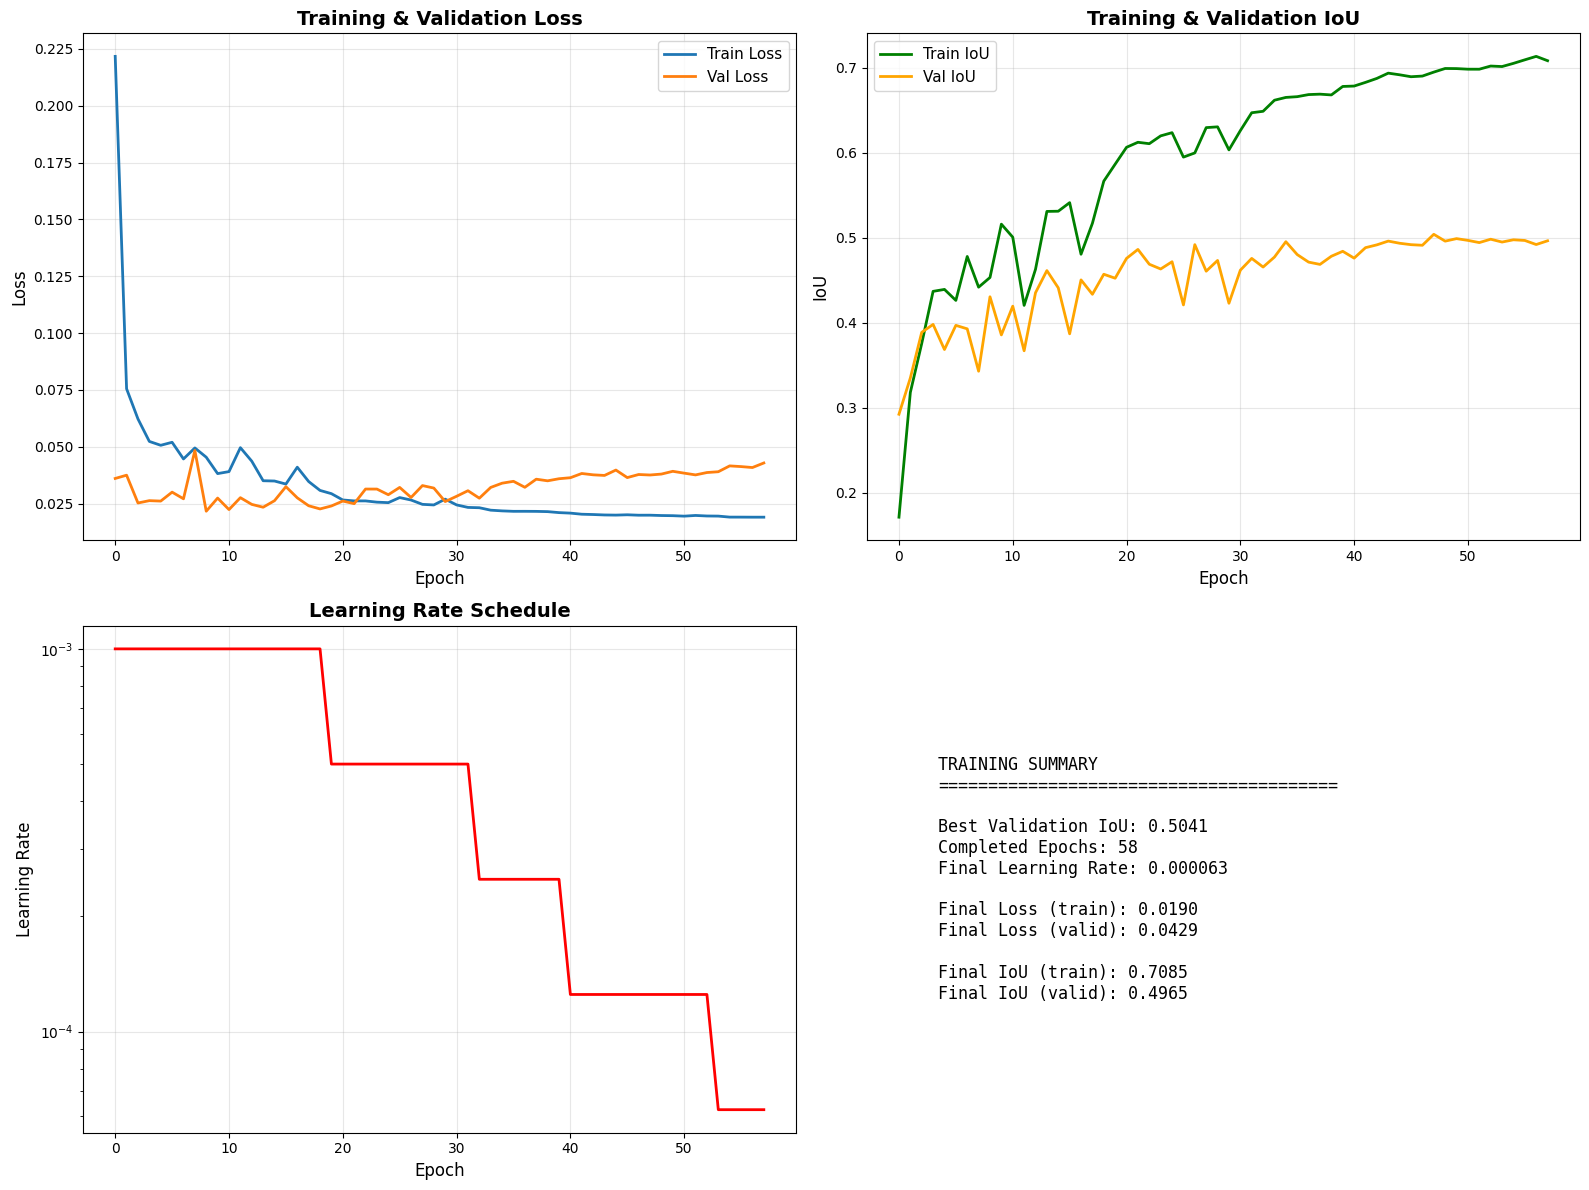

✓ Curves saved in /workspace/data/training_curves_segmentation.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# IoU
axes[0, 1].plot(history['train_iou'], label='Train IoU', linewidth=2, color='green')
axes[0, 1].plot(history['val_iou'], label='Val IoU', linewidth=2, color='orange')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('IoU', fontsize=12)
axes[0, 1].set_title('Training & Validation IoU', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Learning Rate
axes[1, 0].plot(history['lr'], color='red', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Summary
axes[1, 1].axis('off')
summary_text = f"""
TRAINING SUMMARY
{'='*40}

Best Validation IoU: {best_val_iou:.4f}
Completed Epochs: {len(history['train_loss'])}
Final Learning Rate: {history['lr'][-1]:.6f}

Final Loss (train): {history['train_loss'][-1]:.4f}
Final Loss (valid): {history['val_loss'][-1]:.4f}

Final IoU (train): {history['train_iou'][-1]:.4f}
Final IoU (valid): {history['val_iou'][-1]:.4f}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
               verticalalignment='center')

plt.tight_layout()
plt.savefig('/workspace/data/training_curves_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Curves saved in /workspace/data/training_curves_segmentation.png")

## 12b. Training Optimizations Summary

### Applied Optimizations:

**1. Learning Rate Management** ✓
- Changed from fixed LR (0.001) to `ReduceLROnPlateau` scheduler
- Monitors: **Validation IoU (MAXIMUM mode)** - more stable than loss
- Settings: factor=0.1 (10x reduction), patience=3 epochs
- Automatically reduces LR when validation IoU plateaus
- Verbose logging shows when LR changes

**2. Loss Function Enhancement** ✓
- Replaced standard CrossEntropyLoss with **Combined Loss**
- Components:
  - **Dice Loss (50%)**: Handles small object segmentation
  - **Weighted CrossEntropy (50%)**: Balances class imbalance
- Class weights calculated from pixel frequency in training set
- Rare classes (logo, vent) get higher weights (~10-20x)

**3. Data Augmentation** ✓
- **Training set ONLY** (validation remains unchanged):
  - RandomHorizontalFlip (50% probability)
  - ColorJitter (brightness, contrast, saturation, hue)
  - RandomRotation (±10 degrees)
- Helps with generalization on small validation set (131 images)

**4. Training Logic Improvements** ✓
- **Checkpointing**: Saves epoch, model, optimizer, scheduler state
- **Early Stopping**: patience=10 epochs (allows scheduler to work)
- **Per-Class Metrics**: Shows IoU for each class (identifies bottlenecks)
- **Detailed Logging**: Dice + CE loss components shown separately

**5. Architecture Validation** ✓
- Validates `NUM_CLASSES == len(CLASS_NAMES)` consistency
- Checks COCO category IDs don't exceed NUM_CLASSES
- Warns about potential index errors


KeyError: 'train_dice'

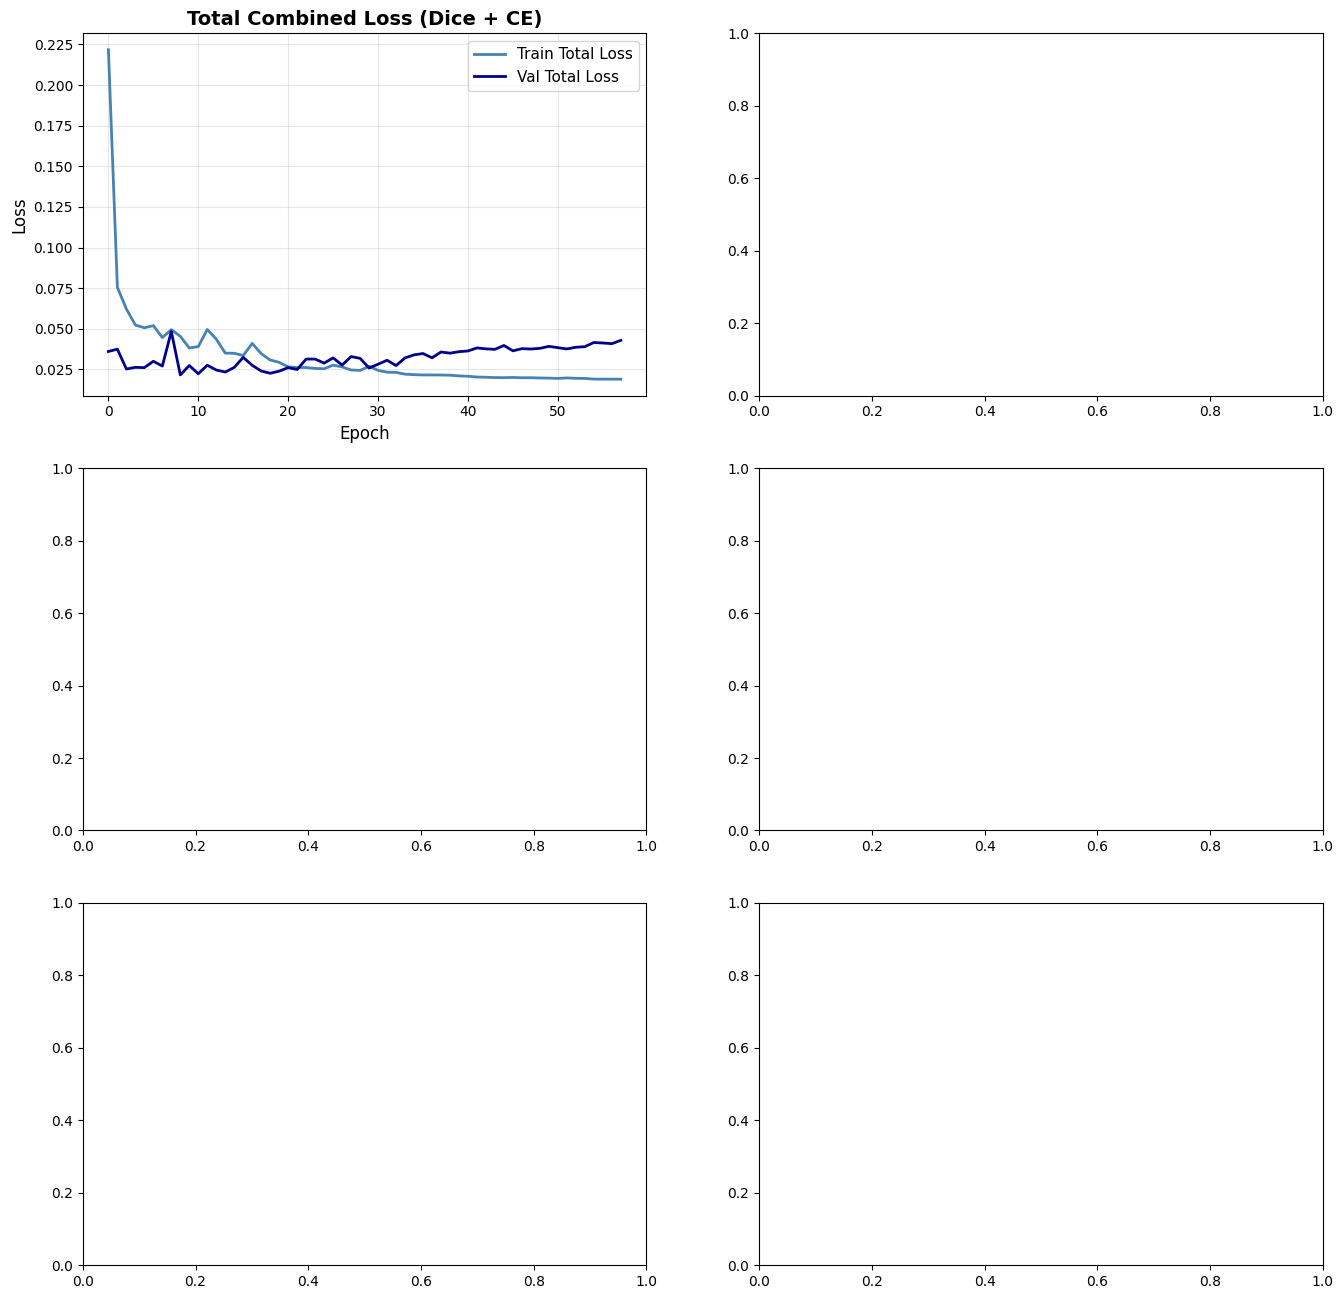

In [15]:
## 12c. Advanced Training Curves with Dice/CE Breakdown

fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# Loss breakdown
axes[0, 0].plot(history['train_loss'], label='Train Total Loss', linewidth=2, color='steelblue')
axes[0, 0].plot(history['val_loss'], label='Val Total Loss', linewidth=2, color='darkblue')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Total Combined Loss (Dice + CE)', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Dice Loss
axes[0, 1].plot(history['train_dice'], label='Train Dice Loss', linewidth=2, color='green')
axes[0, 1].plot(history['val_dice'], label='Val Dice Loss', linewidth=2, color='darkgreen')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Dice Loss', fontsize=12)
axes[0, 1].set_title('Dice Loss Component', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Cross Entropy Loss
axes[1, 0].plot(history['train_ce'], label='Train CE Loss', linewidth=2, color='orange')
axes[1, 0].plot(history['val_ce'], label='Val CE Loss', linewidth=2, color='darkorange')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('CE Loss', fontsize=12)
axes[1, 0].set_title('Cross Entropy Loss Component', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# IoU
axes[1, 1].plot(history['train_iou'], label='Train IoU', linewidth=2, color='green')
axes[1, 1].plot(history['val_iou'], label='Val IoU', linewidth=2, color='orange')
axes[1, 1].axhline(y=best_val_iou, color='red', linestyle='--', linewidth=2, label=f'Best: {best_val_iou:.4f}')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('IoU', fontsize=12)
axes[1, 1].set_title('Training & Validation IoU', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# Learning Rate
axes[2, 0].plot(history['lr'], color='red', linewidth=2)
axes[2, 0].set_xlabel('Epoch', fontsize=12)
axes[2, 0].set_ylabel('Learning Rate', fontsize=12)
axes[2, 0].set_title('Learning Rate Schedule (ReduceLROnPlateau)', fontsize=14, fontweight='bold')
axes[2, 0].set_yscale('log')
axes[2, 0].grid(True, alpha=0.3)

# Per-class IoU heatmap (last epoch)
if history['per_class_iou']:
    last_epoch_per_class = history['per_class_iou'][-1]
    class_names_short = [name[:20] for name in CLASS_NAMES]  # Shorten for display
    ious_last = [iou if not np.isnan(iou) else 0 for _, iou in last_epoch_per_class]
    
    colors = ['green' if iou > 0.7 else 'orange' if iou > 0.5 else 'red' for iou in ious_last]
    bars = axes[2, 1].barh(range(len(class_names_short)), ious_last, color=colors, alpha=0.7)
    
    # Add value labels on bars
    for i, (bar, iou) in enumerate(zip(bars, ious_last)):
        axes[2, 1].text(iou, i, f' {iou:.3f}', va='center', fontsize=9)
    
    axes[2, 1].set_yticks(range(len(class_names_short)))
    axes[2, 1].set_yticklabels(class_names_short, fontsize=9)
    axes[2, 1].set_xlabel('IoU', fontsize=12)
    axes[2, 1].set_title('Per-Class IoU (Last Epoch)', fontsize=14, fontweight='bold')
    axes[2, 1].set_xlim([0, 1])
    axes[2, 1].axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Good: 0.7')
    axes[2, 1].axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Fair: 0.5')
    axes[2, 1].legend(fontsize=10)
    axes[2, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/workspace/data/training_curves_detailed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Detailed training curves saved to /workspace/data/training_curves_detailed.png")


## 13. Extract Trained Backbone

In [16]:
# Load best model
checkpoint = torch.load('/workspace/data/best_segmentation_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Model loaded (epoch {checkpoint['epoch']})")
print(f"✓ Best IoU: {checkpoint['val_iou']:.4f}")

# Extract backbone
trained_backbone = model.backbone

# Save backbone (only backbone weights, much lighter)
torch.save(
    trained_backbone.state_dict(),
    '/workspace/data/backbone_segmentation_trained.pth'
)

print("\n✓ Trained backbone extracted and saved!")
print(f"   Path: /workspace/data/backbone_segmentation_trained.pth")
print(f"\nThis backbone now has optimized features for:")
for i, class_name in enumerate(CLASS_NAMES):
    print(f"  • {class_name}")

✓ Model loaded (epoch 48)
✓ Best IoU: 0.5041

✓ Trained backbone extracted and saved!
   Path: /workspace/data/backbone_segmentation_trained.pth

This backbone now has optimized features for:
  • HVAC-TE7b-xd4I-nNKl-f9NC-HV-x8J2
  • DOWN_BLAST
  • EXV
  • GRAVITY_VENT
  • MAKE_UP_AIR_UNIT
  • MEGA_UNIT
  • MULTI_SPLIT_SYSTEM
  • OTHER
  • REFRIGERATOR
  • RTU
  • STANDARD_AIR_CONDITIONER
  • UP_BLAST
  • VRF_SYSTEM
  • WINDOW-UNIT
  • brand
  • coil
  • fan
  • logo
  • vent


## 14. Visualize Model Predictions

Model predictions on validation set:


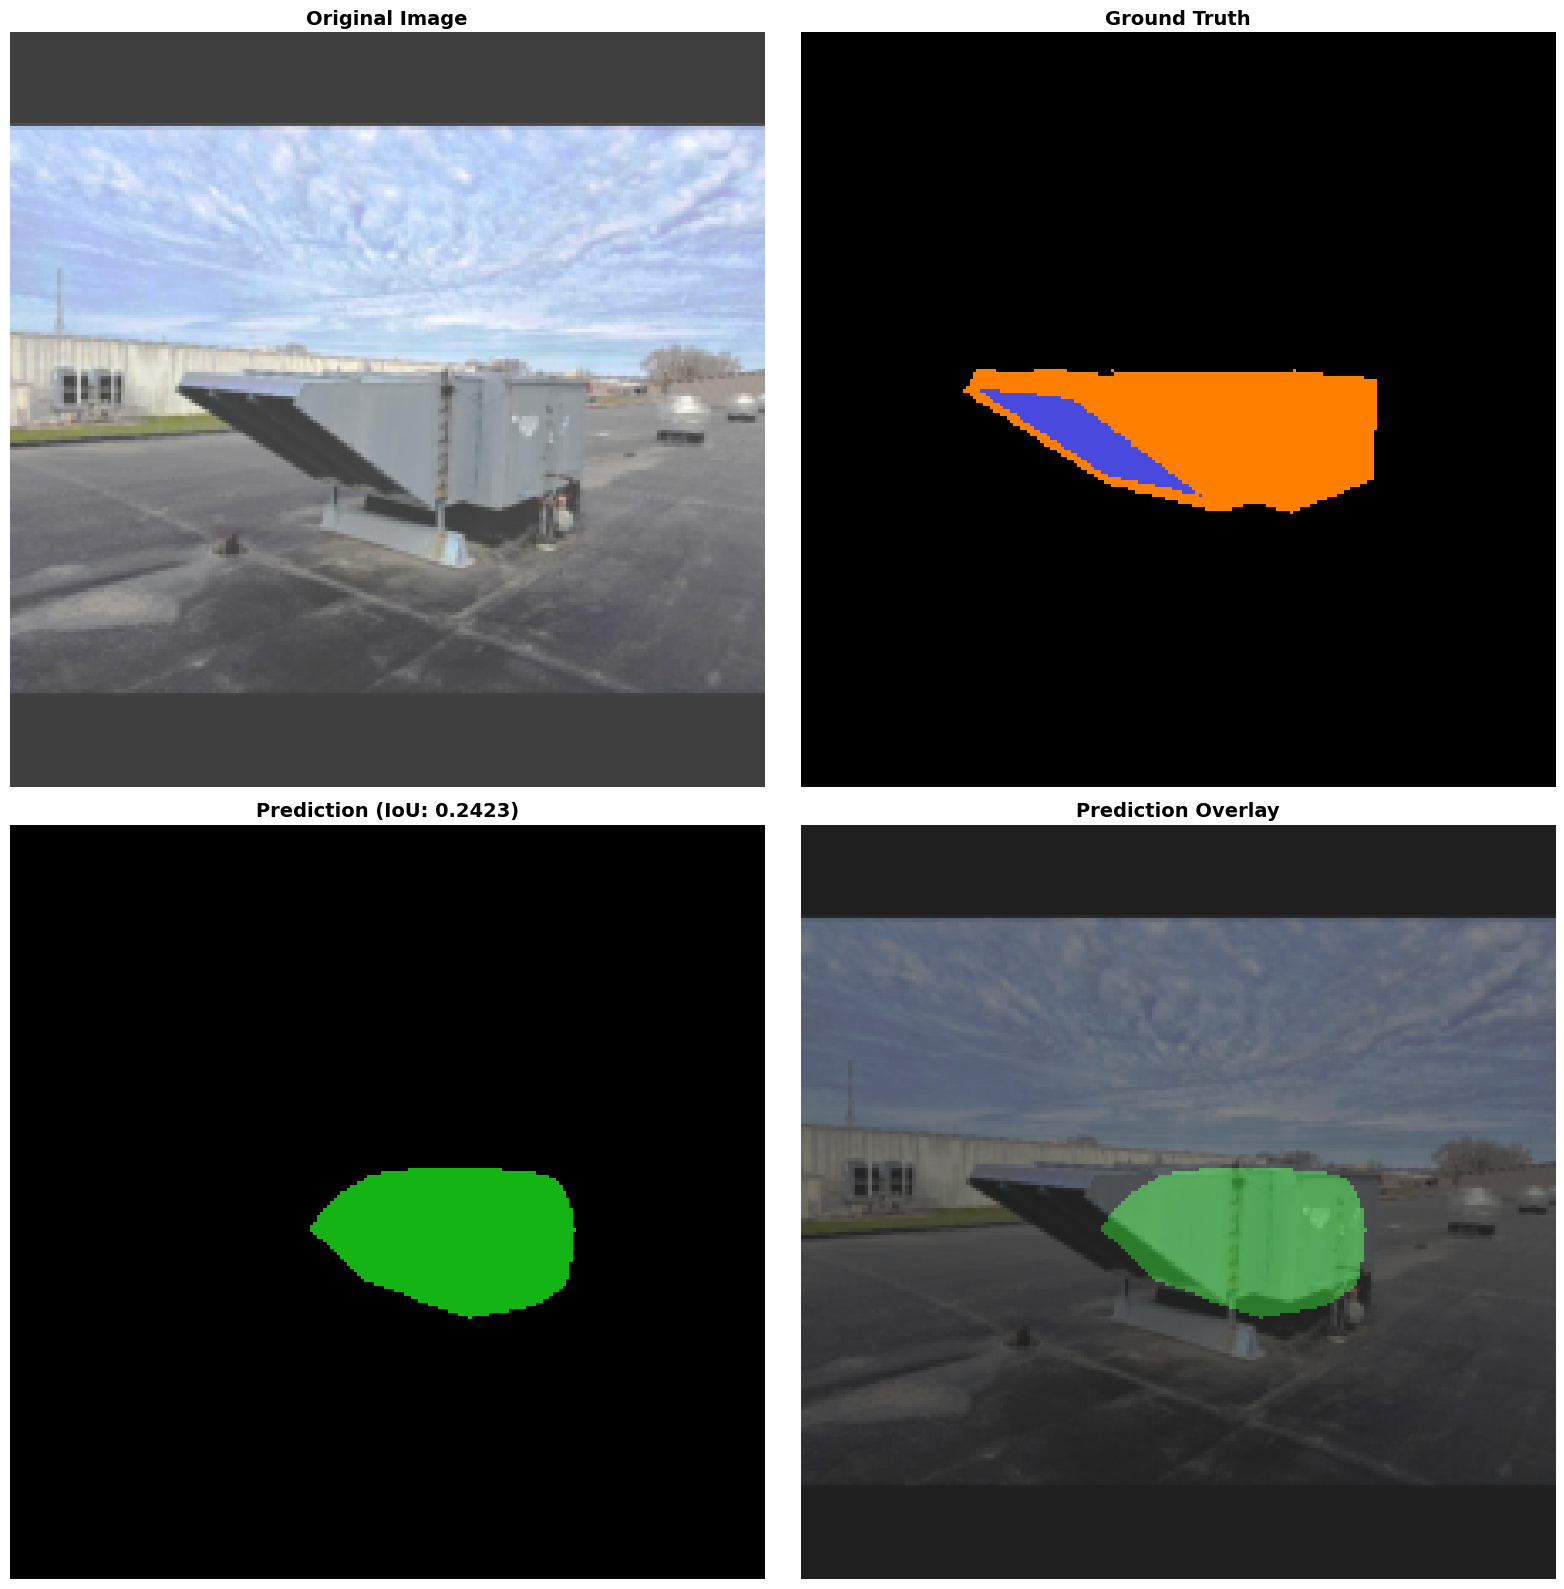

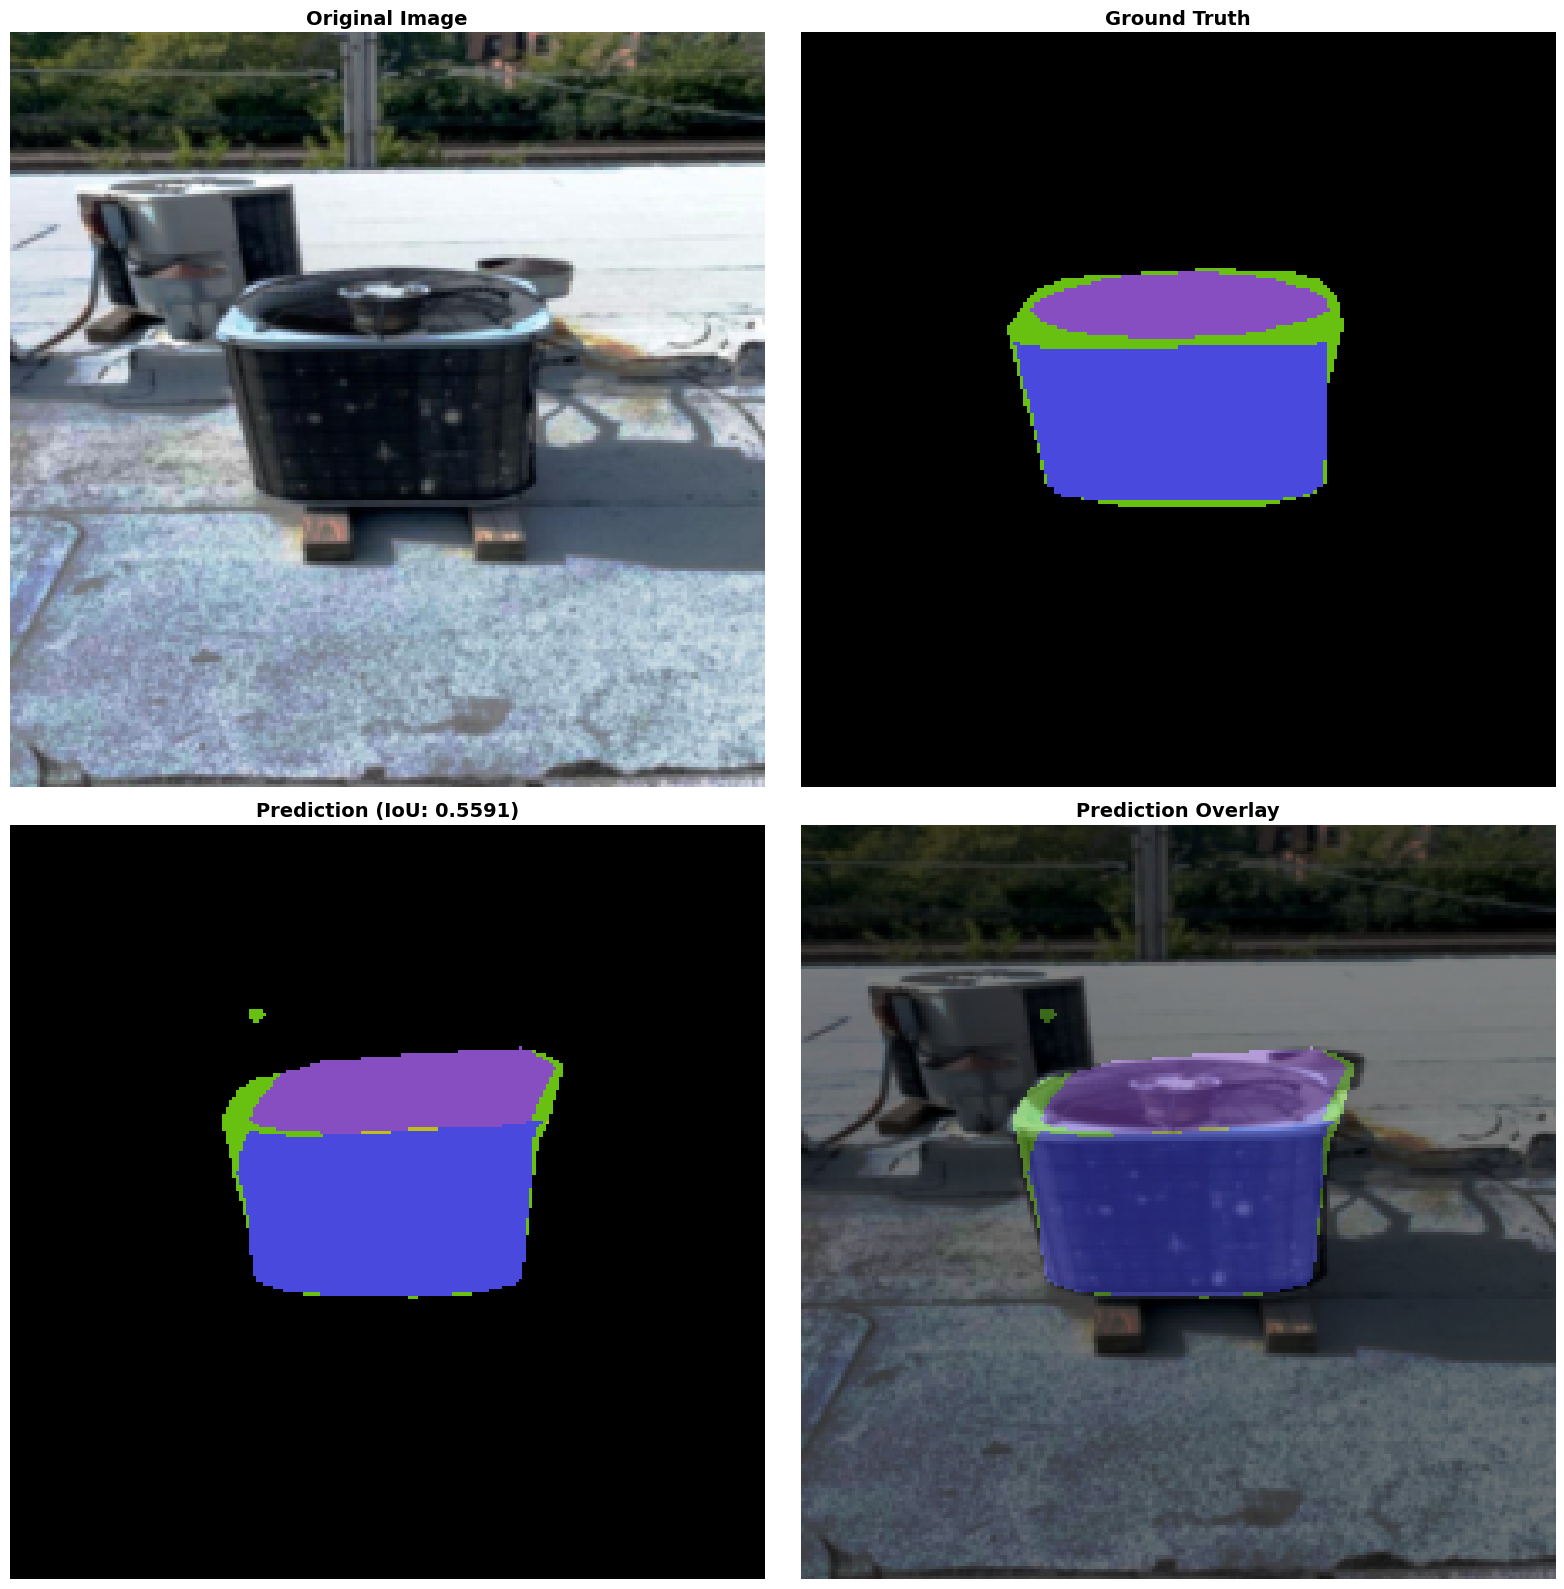

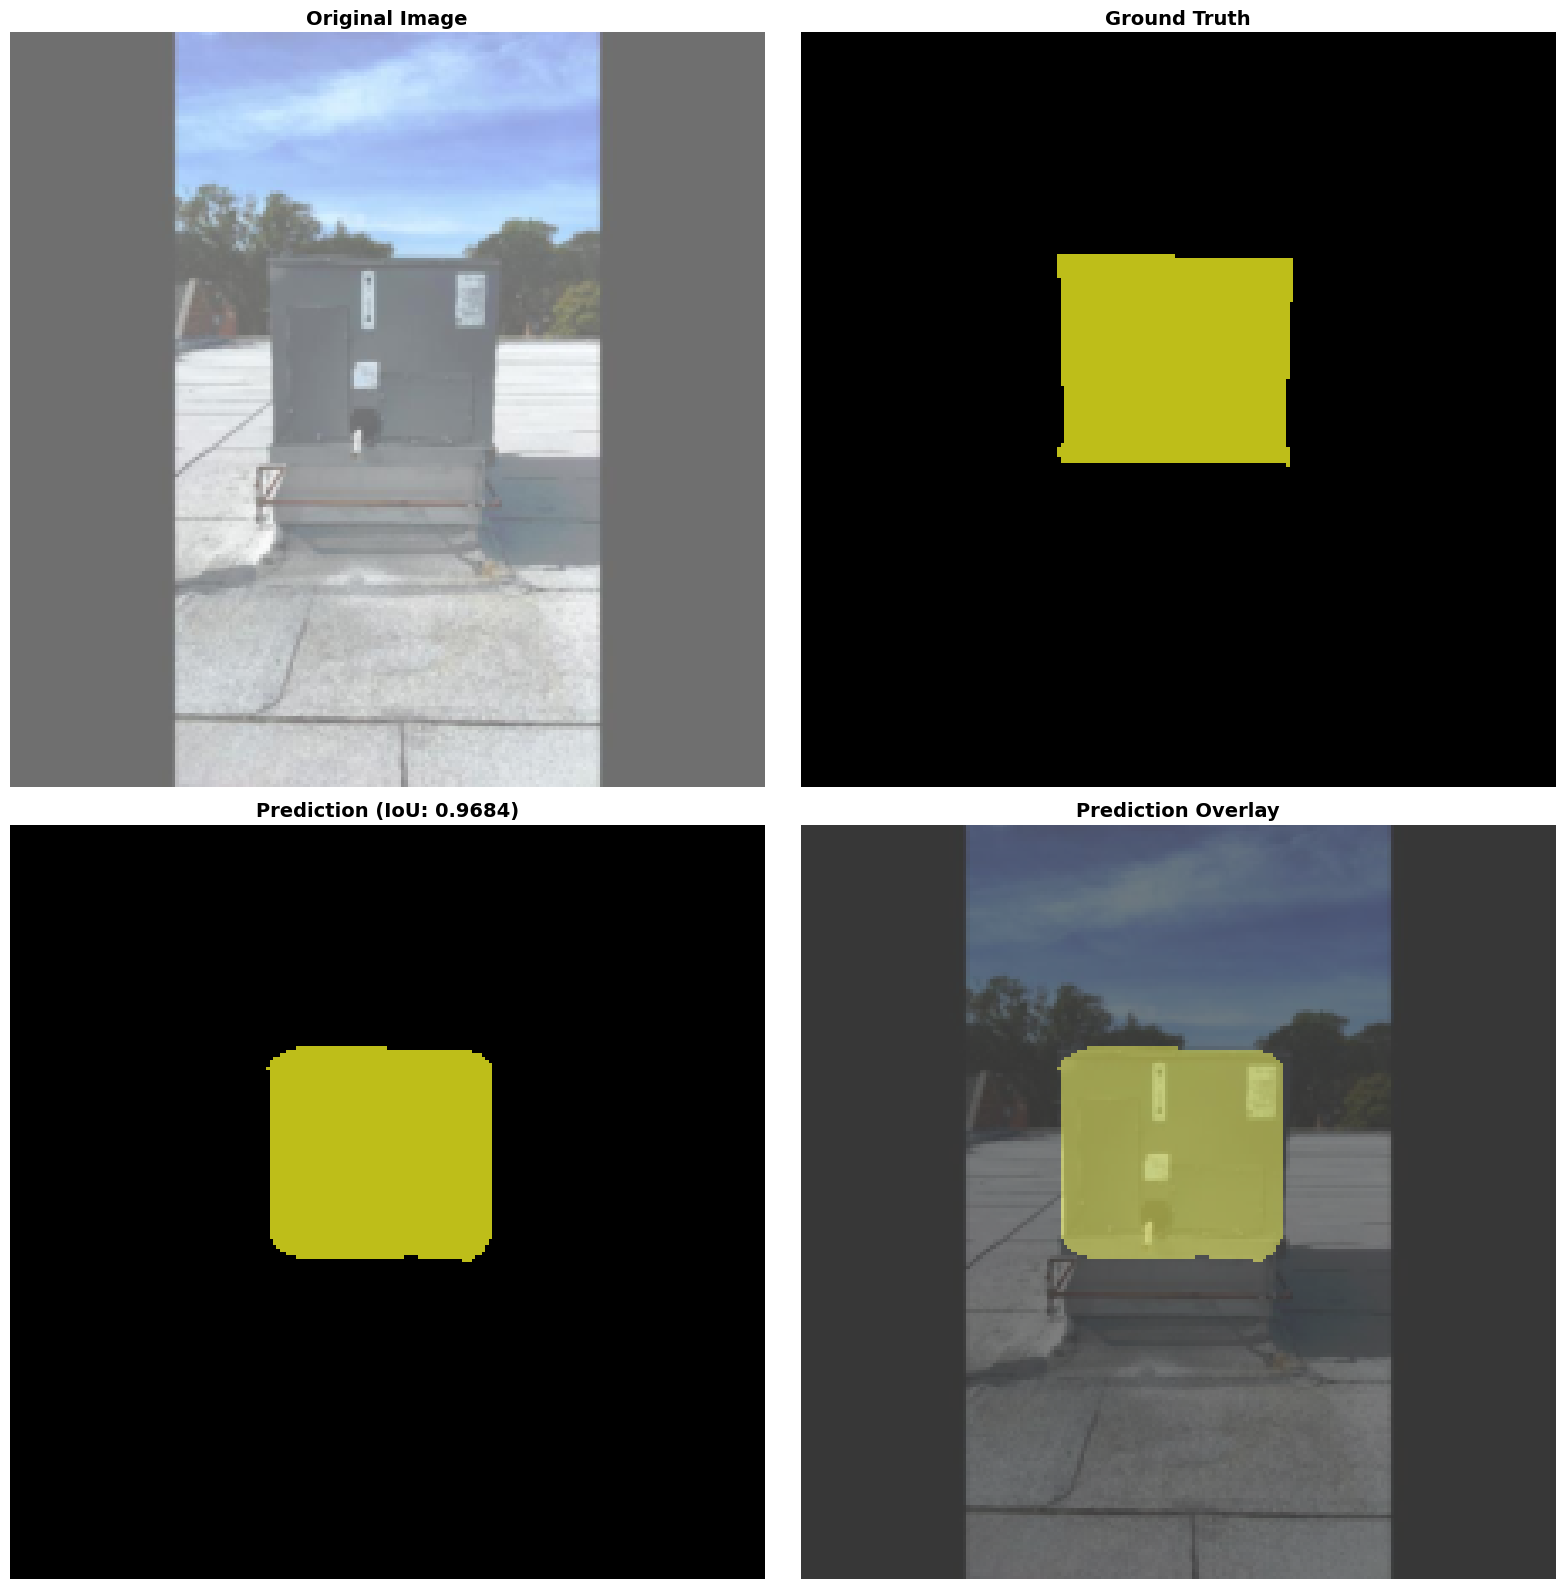

In [44]:
def visualize_prediction(model, dataset, idx, class_names, color_palette):
    """Visualizes model prediction"""
    model.eval()
    
    img, mask_gt = dataset[idx]
    
    # Prediction
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        pred = output['out'].argmax(dim=1).squeeze(0).cpu().numpy()
    
    # Denormalize image
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_denorm = img * std + mean
    img_denorm = img_denorm.permute(1, 2, 0).numpy()
    img_denorm = np.clip(img_denorm, 0, 1)
    
    # Create colored masks
    mask_gt_np = mask_gt.numpy()
    mask_gt_colored = np.zeros((*mask_gt_np.shape, 3), dtype=np.uint8)
    mask_pred_colored = np.zeros((*pred.shape, 3), dtype=np.uint8)
    
    for class_id in range(len(class_names)):
        mask_gt_colored[mask_gt_np == class_id] = color_palette[class_id]
        mask_pred_colored[pred == class_id] = color_palette[class_id]
    
    # Calculate IoU
    iou = calculate_iou(torch.from_numpy(pred), mask_gt, len(class_names))
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    
    axes[0, 0].imshow(img_denorm)
    axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(mask_gt_colored)
    axes[0, 1].set_title('Ground Truth', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(mask_pred_colored)
    axes[1, 0].set_title(f'Prediction (IoU: {iou:.4f})', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(img_denorm)
    axes[1, 1].imshow(mask_pred_colored, alpha=0.5)
    axes[1, 1].set_title('Prediction Overlay', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Visualize predictions on validation set
print("Model predictions on validation set:")
print("=" * 70)
for i in np.random.choice(len(valid_dataset), min(3, len(valid_dataset)), replace=False):
    visualize_prediction(model, valid_dataset, i, CLASS_NAMES, COLOR_PALETTE)

## 15. Compare Attention Maps: COCO vs Trained

This is the key part: visualize how the backbone's attention changed after training.

In [18]:
# Import visualization functions from utils
import sys
sys.path.append('/workspace/notebooks')
from utils import compare_backbone_attention, visualize_embedding_attention

# Load vanilla model (COCO pre-trained)
vanilla_model = deeplabv3_mobilenet_v3_large(weights='DEFAULT', num_classes=21)
vanilla_model = vanilla_model.to(device)
vanilla_model.eval()

# Your trained backbone is already loaded as trained_backbone

# Preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225]),
])


Using sample image: /workspace/notebooks/hvac-segmentation-automatic-flow-8/valid/3ae10519-e6c2-44be-ad22-a5ea9543ea04_filename6256D350-435A-4FE0-94A6-1D2353934764_jpg.rf.d2bb7fff82284f3eb95abb2918321bdd.jpg

ATTENTION MAPS COMPARISON

1. COCO PRE-TRAINED BACKBONE (without fine-tuning)
----------------------------------------------------------------------


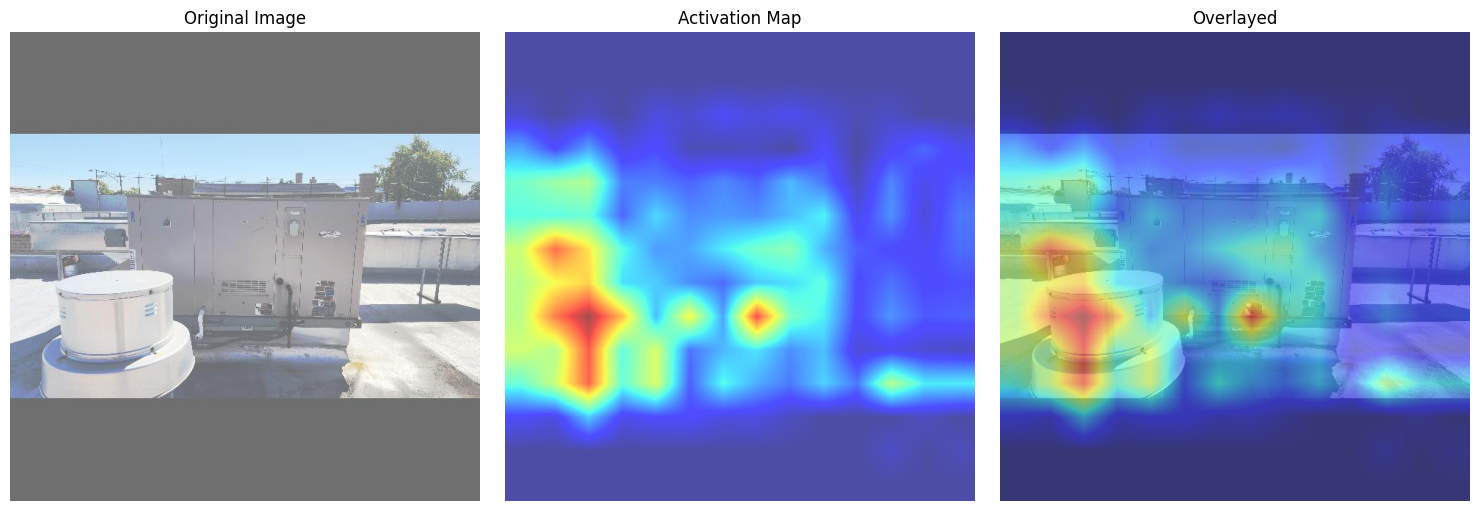


2. BACKBONE TRAINED ON DATASET
----------------------------------------------------------------------


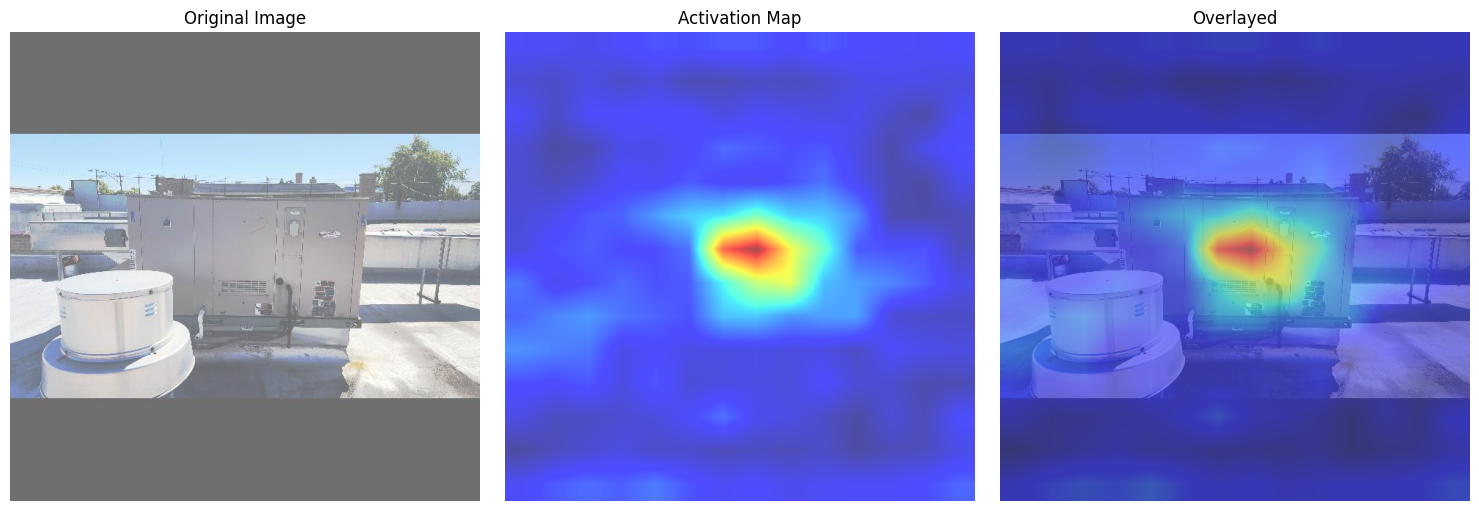


3. SIDE BY SIDE COMPARISON
----------------------------------------------------------------------


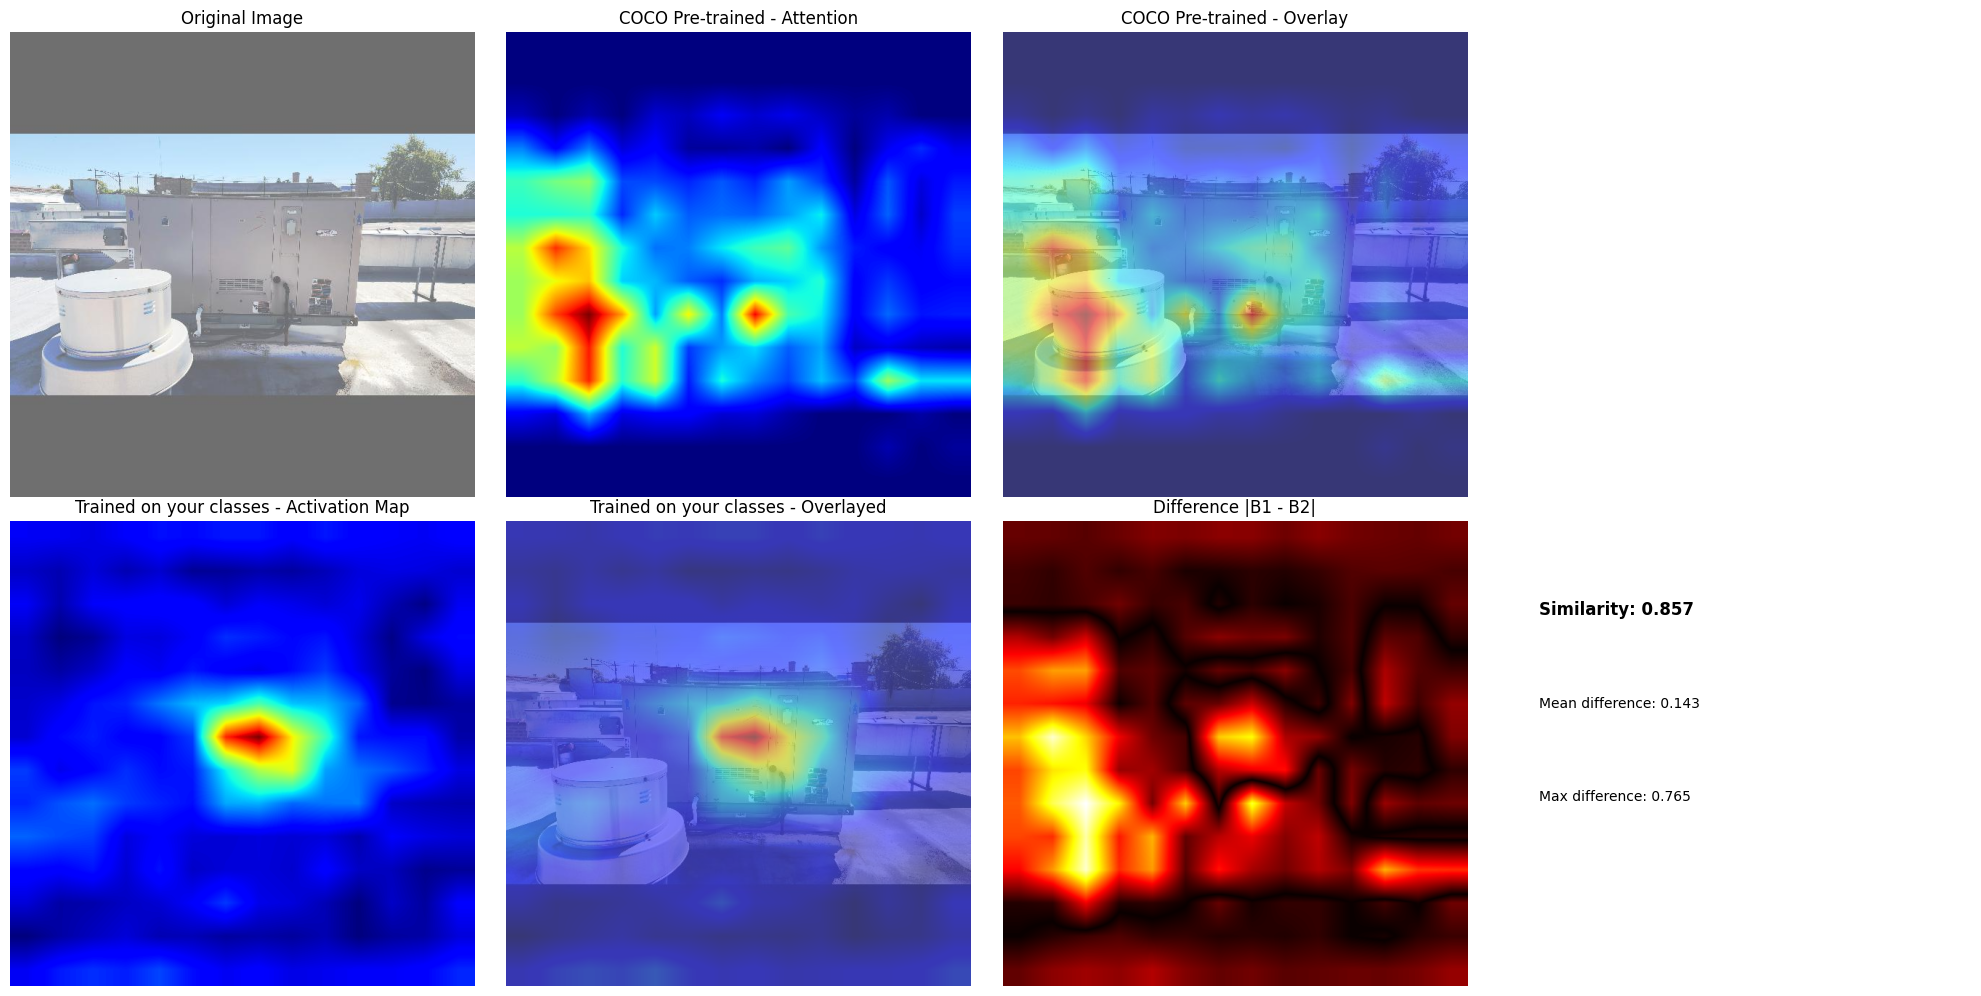


ATTENTION MAPS INTERPRETATION

🔴 RED/YELLOW = High activation (important regions)
🟢 GREEN = Medium activation
🔵 BLUE = Low activation (ignored regions)

EXPECTED CHANGES after training:
✓ More focused attention on specific components from your dataset
✓ Less dispersion in irrelevant areas (background, shadows)
✓ Higher activation in regions with your classes of interest

COMPARISON:
• Similarity < 0.5 → Backbones attend VERY different regions (GOOD!)
• Similarity > 0.8 → Backbones are almost identical (little change)
    


In [60]:
# Select a sample image
# Use an image from your validation dataset
import os

# Get list of validation images
valid_images_dir = DATASET_PATH / "valid" / "images" if (DATASET_PATH / "valid" / "images").exists() else DATASET_PATH / "valid"
sample_images = list(valid_images_dir.glob("*.jpg")) + list(valid_images_dir.glob("*.png"))

if len(sample_images) > 0:
    # Use first image as example
    sample_image_path = str(sample_images[33].resolve())  # .resolve() converts to absolute path
    #sample_image_path = "/workspace/hvac-segmentation-automatic-flow-8/valid/0ad0132c-d61b-428c-9ad9-326199343e6c_1756320924_303535_jpg.rf.a32f1b35225273189c817933633d65d5.jpg"
    #sample_image_path = "assets/vrf/rtu.jpg"
    print(f"Using sample image: {sample_image_path}")
    
    print("\n" + "="*70)
    print("ATTENTION MAPS COMPARISON")
    print("="*70)
    print("\n1. COCO PRE-TRAINED BACKBONE (without fine-tuning)")
    print("-" * 70)
    
    # Visualize vanilla model attention
    visualize_embedding_attention(
        sample_image_path,
        vanilla_model,
        preprocess,
        device='cuda'
    )
    
    print("\n2. BACKBONE TRAINED ON DATASET")
    print("-" * 70)
    
    # Visualize trained model attention
    visualize_embedding_attention(
        sample_image_path,
        model,
        preprocess,
        device='cuda'
    )
    
    print("\n3. SIDE BY SIDE COMPARISON")
    print("-" * 70)
    
    # Compare both backbones
    compare_backbone_attention(
        sample_image_path,
        vanilla_model.backbone,
        trained_backbone,
        preprocess,
        name1="COCO Pre-trained",
        name2="Trained on your classes",
        device='cuda'
    )
    
    print("\n" + "="*70)
    print("ATTENTION MAPS INTERPRETATION")
    print("="*70)
    print("""
🔴 RED/YELLOW = High activation (important regions)
🟢 GREEN = Medium activation
🔵 BLUE = Low activation (ignored regions)

EXPECTED CHANGES after training:
✓ More focused attention on specific components from your dataset
✓ Less dispersion in irrelevant areas (background, shadows)
✓ Higher activation in regions with your classes of interest

COMPARISON:
• Similarity < 0.5 → Backbones attend VERY different regions (GOOD!)
• Similarity > 0.8 → Backbones are almost identical (little change)
    """)
    print("="*70)
    
else:
    print("❌ No validation images found")
    print("   Use your own images for comparison")
    print("\nUsage example:")
    print("""
from utils import compare_backbone_attention

compare_backbone_attention(
    "path/to/your/image.jpg",
    vanilla_model.backbone,
    trained_backbone,
    preprocess,
    "COCO Pre-trained",
    "Trained on your classes"
)
    """)

## 16. Summary and Next Steps

In [14]:
print("="*70)
print("COMPLETE SUMMARY")
print("="*70)
print(f"""
✓ Trained model: DeepLabV3 + MobileNetV3-Large
✓ Number of classes: {NUM_CLASSES}
✓ Best validation IoU: {best_val_iou:.4f}
✓ Completed epochs: {len(history['train_loss'])}

SAVED FILES:
• Full model: /workspace/data/best_segmentation_model.pth
• Trained backbone: /workspace/data/backbone_segmentation_trained.pth
• Training curves: /workspace/data/training_curves_segmentation.png

HOW TO USE THE BACKBONE IN YOUR EMBEDDINGS NOTEBOOK:

1. Load the trained backbone:
   ```python
   def load_trained_backbone(backbone_path):
       from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
       model = deeplabv3_mobilenet_v3_large(weights=None, num_classes={NUM_CLASSES})
       backbone_state_dict = torch.load(backbone_path)
       model.backbone.load_state_dict(backbone_state_dict)
       return model.backbone
   
   trained_backbone = load_trained_backbone(
       '/workspace/data/backbone_segmentation_trained.pth'
   )
   ```

2. Use with your TrainedBackboneEmbeddings class:
   ```python
   embedder = TrainedBackboneEmbeddings(
       'backbone_segmentation_trained.pth'
   )
   embeddings, paths = embedder.get_embeddings_from_folder("assets/")
   ```

3. Compare with vanilla backbone:
   ```python
   from utils import compare_backbone_attention
   
   vanilla_model = deeplabv3_mobilenet_v3_large(weights='DEFAULT')
   
   compare_backbone_attention(
       "assets/vrf/snapshot_0.jpg",
       vanilla_model.backbone,
       trained_backbone,
       preprocess,
       "COCO",
       "Trained on {', '.join(CLASS_NAMES[1:])}"
   )
   ```

NEXT STEPS:
1. Evaluate the model on more images
2. Adjust hyperparameters if necessary
3. Compare embeddings generated with both backbones
4. Analyze which backbone works better for your specific task

""")
print("="*70)

COMPLETE SUMMARY


NameError: name 'best_val_iou' is not defined

## 17. Function to Extract Embeddings

Utility function to extract embeddings from any image using the trained backbone.

In [3]:
def get_embeddings_from_image(image_path, model_path, device='cuda', show_attention=True):
    """
    Extracts embeddings from an image using a trained backbone.
    
    Args:
        image_path (str): Path to the image (absolute or relative)
        model_path (str): Path to the trained backbone .pth file
        device (str): 'cuda' or 'cpu'
        show_attention (bool): If True, visualizes the attention map
    
    Returns:
        numpy.ndarray: Embedding array with shape (embedding_dim,)
    
    Example:
        >>> embeddings = get_embeddings_from_image(
        ...     'assets/vrf/rtu.jpg',
        ...     '/workspace/data/backbone_segmentation_trained.pth',
        ...     show_attention=True
        ... )
        >>> print(embeddings.shape)  # (960,) for MobileNetV3-Large
    """
    import torch
    import torch.nn.functional as F
    from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
    from torchvision import transforms
    from PIL import Image
    from pathlib import Path
    import matplotlib.pyplot as plt
    import cv2
    
    # Configure device
    device = torch.device(device if torch.cuda.is_available() else 'cpu')
    
    # Load backbone
    print(f"Loading backbone from: {model_path}")
    model = deeplabv3_mobilenet_v3_large(weights=None, num_classes=NUM_CLASSES)
    
    # Load backbone weights
    backbone_state_dict = torch.load(model_path, map_location=device, weights_only=False)
    
    # If it's a full checkpoint, extract only the backbone
    if 'model_state_dict' in backbone_state_dict:
        full_state_dict = backbone_state_dict['model_state_dict']
        backbone_state_dict = {k.replace('backbone.', ''): v 
                              for k, v in full_state_dict.items() 
                              if k.startswith('backbone.')}
    
    model.backbone.load_state_dict(backbone_state_dict)
    model.backbone.to(device)
    model.backbone.eval()
    
    # Preprocessing (ImageNet normalization)
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225]),
    ])
    
    # Load and preprocess image
    image_path = Path(image_path)
    if not image_path.is_absolute():
        # If relative, try from /workspace
        image_path = Path("/workspace") / image_path
    
    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")
    
    print(f"Loading image: {image_path}")
    original_img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(original_img).unsqueeze(0).to(device)
    
    # Extract features from backbone
    with torch.no_grad():
        # DeepLabV3 backbone returns OrderedDict with multiple levels
        features_dict = model.backbone(img_tensor)
        
        # Get last feature level (most abstract)
        if isinstance(features_dict, dict):
            # For MobileNetV3, main output is in 'out'
            features = features_dict['out']
        else:
            features = features_dict
        
        # Save features for attention visualization
        feature_maps = features
        
        # Global Average Pooling to get fixed-size embedding
        # Shape: [batch, channels, height, width] -> [batch, channels]
        embedding = F.adaptive_avg_pool2d(features, (1, 1))
        embedding = embedding.squeeze(-1).squeeze(-1)  # [batch, channels]
        
        # Convert to numpy
        embedding_np = embedding.cpu().numpy()[0]  # [channels]
    
    print(f"✓ Embedding extracted: shape {embedding_np.shape}")
    
    # Visualize attention map if requested
    if show_attention:
        print("\nGenerating attention map...")
        
        # Average feature maps across channel dimension
        # Shape: [1, channels, H, W] -> [H, W]
        attention_map = torch.mean(feature_maps[0], dim=0).cpu().numpy()
        
        # Normalize to [0, 1]
        attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min() + 1e-8)
        
        # Resize to original image size
        attention_resized = cv2.resize(attention_map, (original_img.size[0], original_img.size[1]))
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # Original image
        axes[0].imshow(original_img)
        axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        
        # Attention map
        im = axes[1].imshow(attention_resized, cmap='jet', interpolation='bilinear')
        axes[1].set_title('Backbone Attention Map\n(Red=High activation)', fontsize=14, fontweight='bold')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
        
        # Overlay
        axes[2].imshow(original_img)
        axes[2].imshow(attention_resized, cmap='jet', alpha=0.5, interpolation='bilinear')
        axes[2].set_title('Overlay: Regions of Interest', fontsize=14, fontweight='bold')
        axes[2].axis('off')
        
        # Embedding info
        info_text = f"""
Embedding Info:
• Dimensions: {embedding_np.shape[0]}
• L2 norm: {np.linalg.norm(embedding_np):.2f}
• Mean: {embedding_np.mean():.4f}
• Std: {embedding_np.std():.4f}
        """
        fig.text(0.5, 0.02, info_text, ha='center', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.12)
        plt.show()
        
        print("✓ Attention map visualized!")
    
    return embedding_np


PROBANDO LA FUNCIÓN CON VISUALIZACIÓN DE ATENCIÓN

1. Extrayendo embeddings con backbone entrenado...
   (con visualización de mapa de atención)
Cargando backbone desde: backbone_segmentation_trained_v5.pth
Cargando imagen: /workspace/assets/vrf/snapshot_5.jpg
✓ Embedding extraído: shape (960,)

Generando mapa de atención...


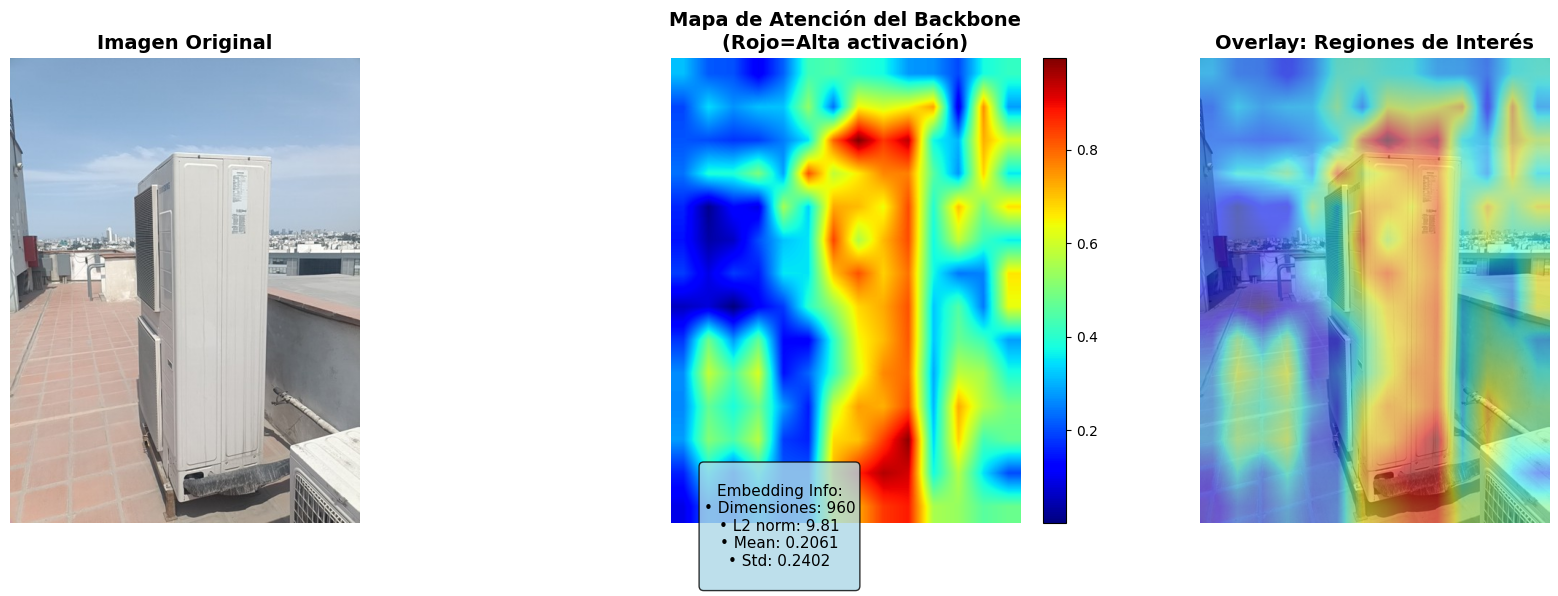

✓ Mapa de atención visualizado!

2. Análisis del embedding:
   • Shape: (960,)
   • Dtype: float32
   • Min value: -0.2365
   • Max value: 1.2228
   • Mean: 0.2061
   • Std: 0.2402
   • L2 norm: 9.8070

3. Distribución del embedding:


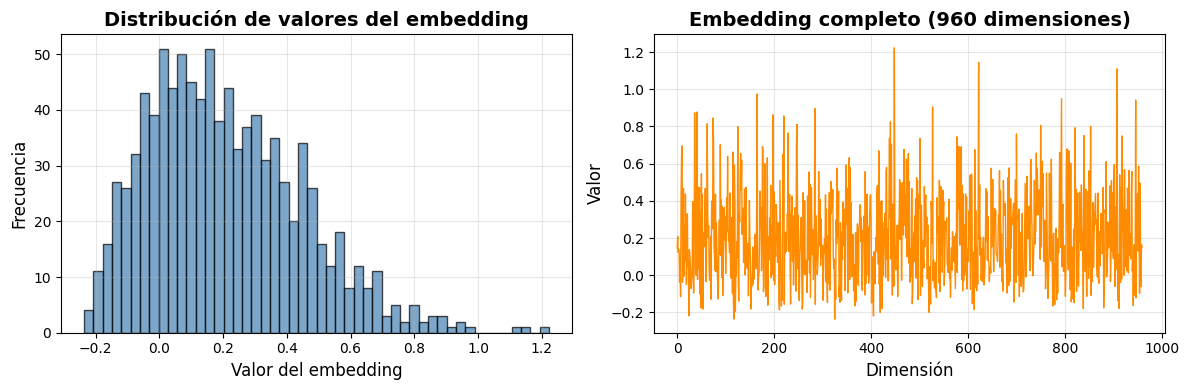


✓ Función funcionando correctamente!
✓ Embeddings listos para usar en comparaciones o búsquedas
✓ Mapa de atención muestra las regiones importantes del backbone


In [6]:
# Test the function with a sample image
print("="*70)
print("TESTING FUNCTION WITH ATTENTION VISUALIZATION")
print("="*70)

# Use sample image
test_image = "assets/vrf/snapshot_5.jpg"

print("\n1. Extracting embeddings with trained backbone...")
print("   (with attention map visualization)")
embeddings_trained = get_embeddings_from_image(
    image_path=test_image,
    model_path='backbone_segmentation_trained_v5.pth',
    device='cuda',
    show_attention=True  # Show attention map!
)

print(f"\n2. Embedding analysis:")
print(f"   • Shape: {embeddings_trained.shape}")
print(f"   • Dtype: {embeddings_trained.dtype}")
print(f"   • Min value: {embeddings_trained.min():.4f}")
print(f"   • Max value: {embeddings_trained.max():.4f}")
print(f"   • Mean: {embeddings_trained.mean():.4f}")
print(f"   • Std: {embeddings_trained.std():.4f}")
print(f"   • L2 norm: {np.linalg.norm(embeddings_trained):.4f}")

# Visualize embedding distribution
print("\n3. Embedding distribution:")
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(embeddings_trained, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Embedding value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Embedding value distribution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(embeddings_trained, linewidth=1, color='darkorange')
plt.xlabel('Dimension', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.title(f'Complete embedding ({len(embeddings_trained)} dimensions)', 
            fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✓ Function working correctly!")
print("✓ Embeddings ready to use for comparisons or searches")
print("✓ Attention map shows important regions for the backbone")
print("="*70)
    